# Fórmulas Completas — Statistisches Lernen 2

**FH Kufstein Tirol — Ian Calixto**

Este notebook reúne e explica **todas as fórmulas** das 4 aulas do curso + o capítulo de Otimização, organizadas por tópico.  
Para cada fórmula: o que é, de onde vem, por que é usada, e como aplicar.

---

## Índice

| Aula | Tópico | Fórmulas Principais |
|------|--------|---------------------|
| **L1** | General Linear Models & Basis Functions | Normal Equation, Basis Functions, RBF, Fourier, B-Splines |
| **L2** | Bias-Variance & Model Selection | Decomposição MSE, Bias², Variance, K-Fold CV |
| **L3** | Regularization & Cross-Validation | Ridge (L2), Lasso (L1), Elastic Net, Dropout, Label Smoothing |
| **L4** | Visão Probabilística & Regularização Bayesiana | Bayes, MAP, MLE, Gaussian Prior→L2, Laplace Prior→L1, Bootstrap |
| **OPT** | Otimização — 1ª e 2ª Ordem | Convexidade, GD, Momentum, Nesterov, SGD, AdaGrad, AdaDelta, Adam, Newton, L-BFGS |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, laplace

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)
print('Pronto.')

Pronto.


---

# AULA 1 — General Linear Models & Basis Functions

---

## Fórmula 1.1 — O Problema do Aprendizado Estatístico

### A Fórmula

$$\boxed{Y = f(\mathbf{x}) + \epsilon}$$

### Cada símbolo

| Símbolo | Significado |
|---------|-------------|
| $Y$ | Variável de saída (o que queremos prever) |
| $\mathbf{x} = (x_1, x_2, \ldots, x_p)$ | Vetor de features de entrada |
| $f$ | Função desconhecida que relaciona $\mathbf{x}$ com $Y$ — nosso objetivo é estimá-la |
| $\epsilon$ | Ruído aleatório com média zero, independente de $\mathbf{x}$ |

### Por que é usada?

Esta equação **formaliza a ideia de que o mundo tem uma parte previsível** ($f(\mathbf{x})$) **e uma parte imprevisível** ($\epsilon$). Todo o aprendizado de máquina supervisionado existe para estimar $f$ a partir de dados.  

- **Prediction:** dado um novo $\mathbf{x}$, queremos $\hat{f}(\mathbf{x}) \approx Y$
- **Inference:** queremos entender como $Y$ muda quando $x_i$ muda

### Meta-insight

O $\epsilon$ define o **teto de desempenho absoluto**: nenhum modelo, por mais sofisticado, consegue prever melhor do que $\sigma^2 = \text{Var}(\epsilon)$. Este é o **Irreducible Error**.

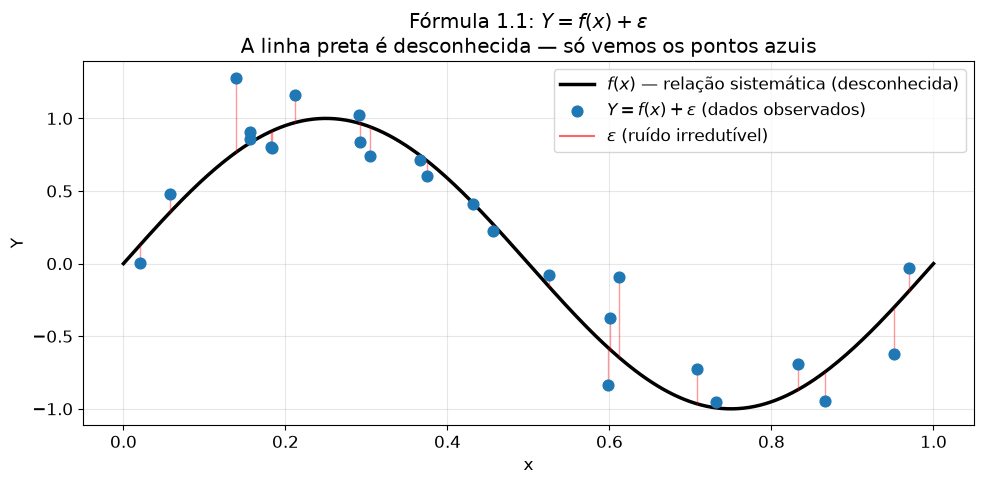

In [2]:
# Visualizando Y = f(x) + epsilon
f = lambda x: np.sin(2 * np.pi * x)
x = np.linspace(0, 1, 300)
x_obs = np.sort(np.random.rand(25))
eps = np.random.normal(0, 0.2, 25)
y_obs = f(x_obs) + eps

plt.figure(figsize=(10, 5))
plt.plot(x, f(x), 'k-', lw=2.5, label='$f(x)$ — relação sistemática (desconhecida)')
plt.scatter(x_obs, y_obs, s=60, color='tab:blue', zorder=5, label='$Y = f(x) + \\epsilon$ (dados observados)')
for xi, yi in zip(x_obs, y_obs):
    plt.plot([xi, xi], [f(xi), yi], 'r-', alpha=0.4, lw=1)
plt.plot([], [], 'r-', alpha=0.6, label='$\\epsilon$ (ruído irredutível)')
plt.xlabel('x'); plt.ylabel('Y')
plt.title('Fórmula 1.1: $Y = f(x) + \\epsilon$\nA linha preta é desconhecida — só vemos os pontos azuis')
plt.legend()
plt.tight_layout()
plt.show()

---

## Fórmula 1.2 — Forma Matricial da Regressão Linear (Design Matrix)

### A Fórmula

$$\boxed{\mathbf{y} = X\mathbf{a} + \boldsymbol{\epsilon}}$$

onde a **Design Matrix** $X \in \mathbb{R}^{K \times (n+1)}$ é:

$$X = \begin{pmatrix} 1 & x_1^1 & x_1^2 & \cdots & x_1^n \\ 1 & x_2^1 & x_2^2 & \cdots & x_2^n \\ \vdots & & & & \vdots \\ 1 & x_K^1 & x_K^2 & \cdots & x_K^n \end{pmatrix}$$

### Cada símbolo

| Símbolo | Significado |
|---------|-------------|
| $\mathbf{y} \in \mathbb{R}^K$ | Vetor com todos os $K$ valores observados |
| $X \in \mathbb{R}^{K \times (n+1)}$ | Design Matrix: linhas = observações, colunas = features |
| $\mathbf{a} \in \mathbb{R}^{n+1}$ | Vetor de coeficientes (o que queremos aprender) |
| $\boldsymbol{\epsilon} \in \mathbb{R}^K$ | Vetor de ruídos |

### Por que a primeira coluna é sempre 1?

A coluna de uns permite que o coeficiente $a_0$ funcione como **intercepto (bias)** — o valor de $y$ quando todas as features são zero. Sem ela, o modelo seria forçado a passar pela origem.

### Por que é útil?

Colocar tudo em forma matricial permite resolver o problema para **todas as observações ao mesmo tempo** com uma única operação de álgebra linear, em vez de um sistema de equações por observação.

In [3]:
# Construindo a Design Matrix manualmente
K = 5  # 5 observações de exemplo
x_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

# Design Matrix com coluna de 1s + x (regressão linear simples)
X = np.column_stack([np.ones(K), x_ex])

print('Design Matrix X (regressão linear simples):')
print('    [  1    x  ]')
print(X)
print(f'\nShape: {X.shape}  →  {K} observações, {X.shape[1]} coeficientes (a0, a1)')

# Grau 2: adicionar coluna x²
X2 = np.column_stack([np.ones(K), x_ex, x_ex**2])
print('\nDesign Matrix X (grau 2: intercepto + x + x²):')
print('    [  1    x    x²  ]')
print(X2)
print(f'Shape: {X2.shape}')

Design Matrix X (regressão linear simples):
    [  1    x  ]
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

Shape: (5, 2)  →  5 observações, 2 coeficientes (a0, a1)

Design Matrix X (grau 2: intercepto + x + x²):
    [  1    x    x²  ]
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]
Shape: (5, 3)


---

## Fórmula 1.3 — Normal Equations (Solução Analítica Exata)

### A Fórmula

$$\boxed{\hat{\mathbf{a}} = (X^T X)^{-1} X^T \mathbf{y}}$$

### Dedução Passo a Passo

**Objetivo:** minimizar o erro quadrático total
$$\mathcal{L}(\mathbf{a}) = \|\mathbf{y} - X\mathbf{a}\|^2 = (\mathbf{y} - X\mathbf{a})^T(\mathbf{y} - X\mathbf{a})$$

**Expandindo:**
$$\mathcal{L}(\mathbf{a}) = \mathbf{y}^T\mathbf{y} - 2\mathbf{a}^T X^T \mathbf{y} + \mathbf{a}^T X^T X \mathbf{a}$$

**Derivando em relação a $\mathbf{a}$ e igualando a zero:**
$$\frac{\partial \mathcal{L}}{\partial \mathbf{a}} = -2X^T\mathbf{y} + 2X^TX\mathbf{a} = 0$$

**Resolvendo (assumindo $X^TX$ invertível):**
$$X^TX\mathbf{a} = X^T\mathbf{y} \implies \hat{\mathbf{a}} = (X^TX)^{-1}X^T\mathbf{y}$$

### Por que é importante?

Esta é uma **solução analítica fechada** — não é uma aproximação, não requer iteração. Em vez de gradient descent (que só converge aproximadamente), esta fórmula dá a resposta exata em uma operação.  

> ⚠️ **Cuidado:** $(X^TX)$ deve ser invertível. Se $X$ tiver colunas linearmente dependentes (features redundantes) ou se $p > K$ (mais features que dados), a matriz é singular. Neste caso, use `np.linalg.lstsq` ou adicione regularização → **Ridge** (Fórmula 3.1).

=== Normal Equation: â = (XᵀX)⁻¹ Xᵀy ===
XᵀX =
[[40.         -6.1541603 ]
 [-6.1541603  54.12732963]]

Xᵀy = [ 42.77110613 112.39055965]

Coeficientes estimados:
  a0 (intercepto) = 1.4135  (verdadeiro: 1.5)
  a1 (inclinação) = 2.2371  (verdadeiro: 2.3)


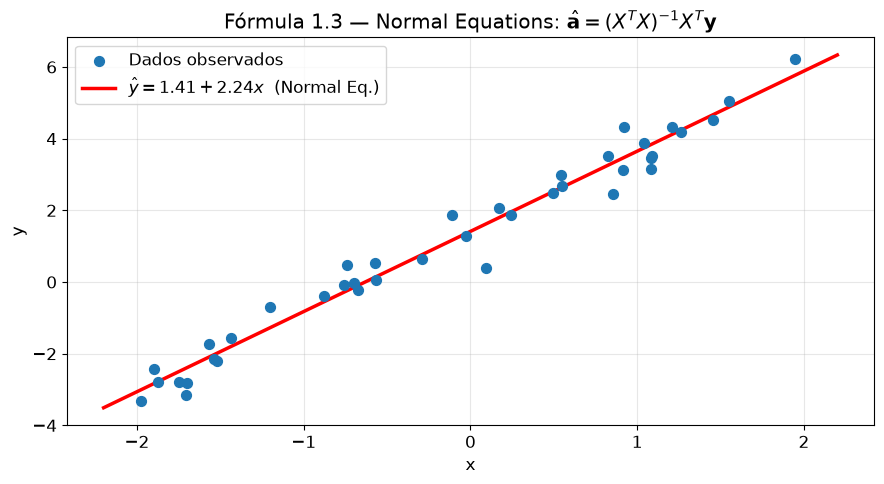

In [4]:
# Aplicando a Normal Equation em dados reais
n_obs = 40
x_lin = np.sort(np.random.uniform(-2, 2, n_obs))
y_lin = 1.5 + 2.3 * x_lin + np.random.normal(0, 0.5, n_obs)

# Construindo X e aplicando a Normal Equation
X = np.column_stack([np.ones(n_obs), x_lin])
a_hat = np.linalg.solve(X.T @ X, X.T @ y_lin)  # solve é mais estável que inverter

print('=== Normal Equation: â = (XᵀX)⁻¹ Xᵀy ===')
print(f'XᵀX =\n{X.T @ X}')
print(f'\nXᵀy = {X.T @ y_lin}')
print(f'\nCoeficientes estimados:')
print(f'  a0 (intercepto) = {a_hat[0]:.4f}  (verdadeiro: 1.5)')
print(f'  a1 (inclinação) = {a_hat[1]:.4f}  (verdadeiro: 2.3)')

x_plot = np.linspace(-2.2, 2.2, 200)
plt.figure(figsize=(9, 5))
plt.scatter(x_lin, y_lin, s=50, label='Dados observados', zorder=5)
plt.plot(x_plot, a_hat[0] + a_hat[1]*x_plot, 'r-', lw=2.5,
         label=f'$\\hat{{y}} = {a_hat[0]:.2f} + {a_hat[1]:.2f}x$  (Normal Eq.)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Fórmula 1.3 — Normal Equations: $\\hat{\\mathbf{a}} = (X^TX)^{-1}X^T\\mathbf{y}$')
plt.legend()
plt.tight_layout()
plt.show()

---

## Fórmula 1.4 — Basis Functions: Modelo Geral

### A Fórmula

$$\boxed{y_j = a_0 + \sum_{m=1}^{M} a_m B_m(x_j) + \epsilon_j}$$

Em forma matricial:

$$\mathbf{y} = B\mathbf{a} + \boldsymbol{\epsilon}, \quad \hat{\mathbf{a}} = (B^T B)^{-1} B^T \mathbf{y}$$

onde a **Basis Matrix** $B \in \mathbb{R}^{K \times M}$ é:
$$B_{j,m} = B_m(x_j)$$

### O truque central

O modelo é **não-linear em $x$** (porque $B_m(x)$ pode ser qualquer função), mas **linear nos coeficientes $a_m$**. Isso preserva toda a simplicidade algébrica da regressão linear!

| O que muda | O que permanece |
|------------|------------------|
| As funções $B_m$ | A fórmula $(B^TB)^{-1}B^T\mathbf{y}$ |
| A forma da curva ajustada | A álgebra linear |
| A matriz $B$ | O método de solução |

### Por que é importante?

Trocar o tipo de basis (polinômio → RBF → Fourier → B-Spline) **não muda o algoritmo de estimação** — apenas muda a matriz $B$. Isso torna o framework extremamente flexível.

---

## Fórmula 1.5 — Polynomial Basis

### A Fórmula

$$\boxed{B_m(x) = x^m, \quad m = 0, 1, 2, \ldots, M}$$

O modelo resultante:
$$y_j = a_0 + a_1 x_j + a_2 x_j^2 + \cdots + a_M x_j^M$$

A Design Matrix polinomial:
$$B_{\text{poly}} = \begin{pmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^M \\ 1 & x_2 & x_2^2 & \cdots & x_2^M \\ \vdots & & & & \vdots \end{pmatrix}$$

### Por que é usada?

- **Vantagem:** a mais simples de construir; captura curvaturas sem sair do framework linear
- **Desvantagem:** graus altos causam oscilações violentas nas bordas (*Runge's phenomenon*) e condicionamento numérico ruim

> **Dica numérica:** para $x \in [0, 3]$ com grau $> 8$, normalize primeiro: $x_n = x / 3.0$ para evitar matrizes mal-condicionadas.

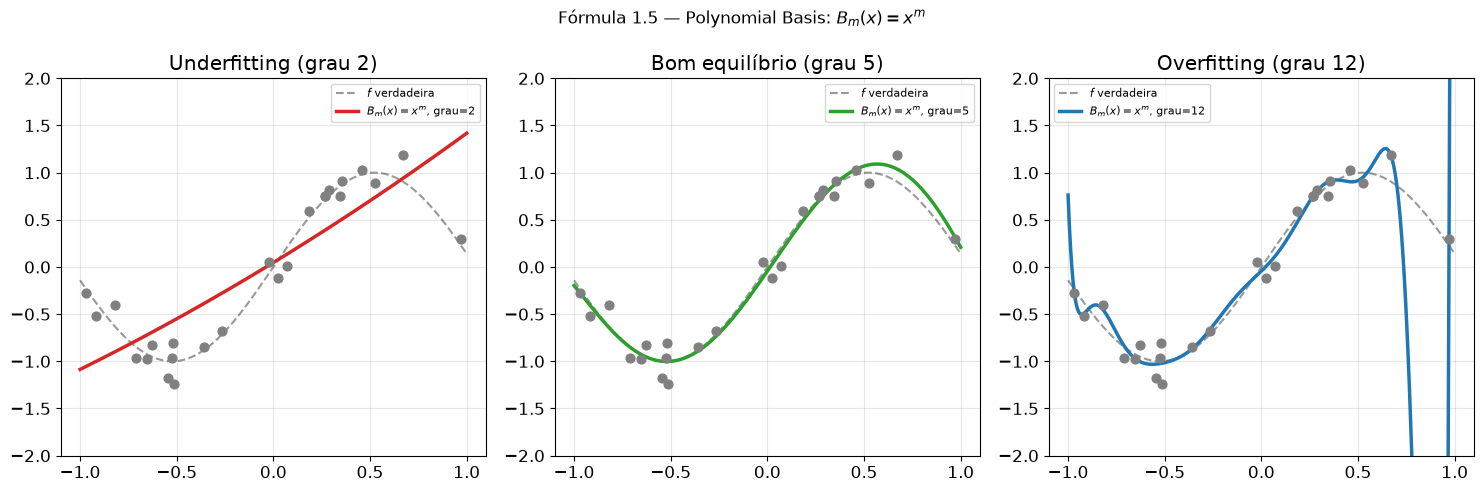

In [5]:
# Comparando graus de Polynomial Basis
x_nl = np.sort(np.random.uniform(-1, 1, 25))
y_nl = np.sin(3 * x_nl) + np.random.normal(0, 0.15, 25)
x_plot = np.linspace(-1, 1, 300)

def poly_basis(x, degree):
    return np.column_stack([x**m for m in range(degree + 1)])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, grau, cor, titulo in zip(axes, [2, 5, 12],
                                  ['tab:red', 'tab:green', 'tab:blue'],
                                  ['Underfitting (grau 2)', 'Bom equilíbrio (grau 5)', 'Overfitting (grau 12)']):
    B_tr = poly_basis(x_nl, grau)
    a = np.linalg.lstsq(B_tr, y_nl, rcond=None)[0]
    y_pred = poly_basis(x_plot, grau) @ a
    ax.scatter(x_nl, y_nl, s=40, color='gray', zorder=5)
    ax.plot(x_plot, np.sin(3*x_plot), 'k--', alpha=0.4, lw=1.5, label='$f$ verdadeira')
    ax.plot(x_plot, y_pred, '-', color=cor, lw=2.5, label=f'$B_m(x)=x^m$, grau={grau}')
    ax.set_title(titulo); ax.set_ylim(-2, 2); ax.legend(fontsize=8)

plt.suptitle('Fórmula 1.5 — Polynomial Basis: $B_m(x) = x^m$', fontsize=12)
plt.tight_layout(); plt.show()

---

## Fórmula 1.6 — Gaussian RBF Basis (Radial Basis Functions)

### A Fórmula

$$\boxed{B_m(x) = \exp\!\left(-\frac{(x - c_m)^2}{2\sigma^2}\right)}$$

| Parâmetro | Nome | Papel |
|-----------|------|-------|
| $c_m$ | **Center** | Onde o sino gaussiano está centrado |
| $\sigma$ | **Width** | Raio de influência do sino |

### Por que é usada?

Diferente dos polinômios (que têm **suporte global** — alterar um coeficiente afeta a curva inteira), as RBFs têm **suporte local**: a função $B_m(x)$ só é significativa perto de $c_m$. Isso torna o modelo mais interpretável e estável.

- $\sigma$ pequeno → sinos estreitos → modelo muito flexível (risco de overfitting)
- $\sigma$ grande → sinos largos → modelo mais suave (risco de underfitting)

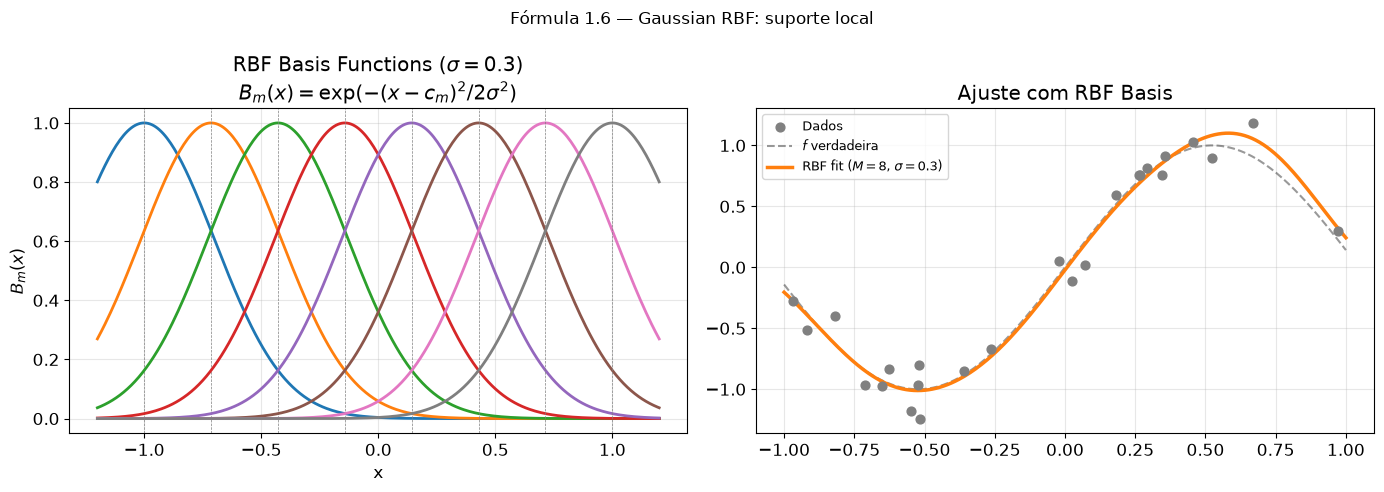

In [6]:
# Visualizando RBF basis functions e ajuste
centers = np.linspace(-1, 1, 8)
sigma = 0.3
x_vis = np.linspace(-1.2, 1.2, 300)

def rbf_basis(x, centers, sigma):
    return np.column_stack([np.exp(-(x - c)**2 / (2*sigma**2)) for c in centers])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for c in centers:
    ax.plot(x_vis, np.exp(-(x_vis-c)**2/(2*sigma**2)), lw=2)
    ax.axvline(c, color='gray', lw=0.5, ls='--')
ax.set_title(f'RBF Basis Functions ($\\sigma={sigma}$)\n$B_m(x) = \\exp(-(x-c_m)^2/2\\sigma^2)$')
ax.set_xlabel('x'); ax.set_ylabel('$B_m(x)$')

ax = axes[1]
B_tr = rbf_basis(x_nl, centers, sigma)
a = np.linalg.lstsq(B_tr, y_nl, rcond=None)[0]
y_pred = rbf_basis(x_plot, centers, sigma) @ a
ax.scatter(x_nl, y_nl, s=40, color='gray', zorder=5, label='Dados')
ax.plot(x_plot, np.sin(3*x_plot), 'k--', alpha=0.4, lw=1.5, label='$f$ verdadeira')
ax.plot(x_plot, y_pred, 'tab:orange', lw=2.5, label=f'RBF fit ($M=8$, $\\sigma={sigma}$)')
ax.set_title('Ajuste com RBF Basis'); ax.legend(fontsize=9)

plt.suptitle('Fórmula 1.6 — Gaussian RBF: suporte local', fontsize=12)
plt.tight_layout(); plt.show()

---

## Fórmula 1.7 — Fourier Basis

### A Fórmula

$$\boxed{B_{2k-1}(x) = \sin\!\left(\frac{2\pi k x}{T}\right), \quad B_{2k}(x) = \cos\!\left(\frac{2\pi k x}{T}\right), \quad k = 1, 2, \ldots, K}$$

O modelo completo:
$$y_j = a_0 + \sum_{k=1}^{K} \left[ a_{2k-1} \sin\!\left(\frac{2\pi k x_j}{T}\right) + a_{2k} \cos\!\left(\frac{2\pi k x_j}{T}\right) \right] + \epsilon_j$$

| Parâmetro | Papel |
|-----------|-------|
| $T$ | Período do dado |
| $k$ | Frequência (harmônico) |

### Por que é usada?

Para dados **periódicos** (temperatura ao longo do ano, sinais de áudio, consumo elétrico diário), senos e cossenos são as bases naturais — poucas frequências capturam padrões complexos. Para dados não-periódicos, prefira RBFs ou B-Splines.

---

## Fórmula 1.8 — B-Splines (Cox-de Boor, Recursão)

### A Fórmula — Grau 0 (base da recursão)

$$B_{m,0}(x) = \begin{cases} 1 & \text{se } t_m \leq x < t_{m+1} \\ 0 & \text{caso contrário} \end{cases}$$

### A Fórmula — Grau $p > 0$ (recursão)

$$\boxed{B_{m,p}(x) = \frac{x - t_m}{t_{m+p} - t_m} B_{m,p-1}(x) + \frac{t_{m+p+1} - x}{t_{m+p+1} - t_{m+1}} B_{m+1,p-1}(x)}$$

onde $t_m$ são os **knots** (nós que dividem o eixo $x$).

### Duas propriedades cruciais

**1. Compact Support (Suporte Compacto):**
$$B_{m,p}(x) = 0 \quad \text{para } x \notin [t_m, t_{m+p+1}]$$

→ Mudar o coeficiente $a_m$ só afeta a curva localmente. Ao contrário de polinômios globais!

**2. Partition of Unity:**
$$\sum_{m} B_{m,p}(x) = 1 \quad \text{para todo } x$$

→ Em qualquer ponto, as B-Splines ativas somam exatamente 1. Isso garante estabilidade numérica.

### Por que é importante?

B-Splines combinam o melhor dos mundos:
- **Localidade** (como RBF) + **suavidade controlável** (pelo grau $p$) + **estabilidade numérica** (Partition of Unity)
- São usadas em CAD, computação gráfica, e regressão não-paramétrica

| Grau | Suavidade |
|------|-----------|
| 1 | Funções lineares por partes (ângulos nas juntas) |
| 2 | Funções quadráticas por partes (suaves na 1ª derivada) |
| 3 | Cúbico — suave na 1ª e 2ª derivada (padrão em engenharia) |

---

# AULA 2 — Bias-Variance Trade-Off & Model Selection

---

## Fórmula 2.1 — Decomposição do Erro Total (MSE)

### A Fórmula

$$\boxed{\text{MSE}(x) = \underbrace{\left(f(x) - \mathbb{E}[\hat{f}(x)]\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\!\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible Error}}}$$

### Dedução Passo a Passo

**Ponto de partida:** $y = f(x) + \epsilon$, onde $\epsilon \sim (0, \sigma^2)$

**Passo 1:** Expandir o MSE
$$\text{MSE}(x) = \mathbb{E}\left[(y - \hat{f}(x))^2\right] = \mathbb{E}\left[(f(x) + \epsilon - \hat{f}(x))^2\right]$$

**Passo 2:** Expandir o quadrado
$$= \mathbb{E}\left[(f(x) - \hat{f}(x))^2\right] + 2\underbrace{\mathbb{E}[(f(x) - \hat{f}(x))\epsilon]}_{=\, 0 \text{ (independência)}} + \underbrace{\mathbb{E}[\epsilon^2]}_{= \sigma^2}$$

**Passo 3:** Adicionar e subtrair $\mathbb{E}[\hat{f}(x)]$ no primeiro termo
$$\mathbb{E}\left[(f(x) - \hat{f}(x))^2\right] = \underbrace{(f(x) - \mathbb{E}[\hat{f}(x)])^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]}_{\text{Variance}}$$

### O que cada componente significa?

| Componente | Fórmula | Causa | Remédio |
|------------|---------|-------|--------|
| **Bias²** | $(f - \mathbb{E}[\hat{f}])^2$ | Modelo muito simples, suposições erradas | Aumentar complexidade |
| **Variance** | $\mathbb{E}[(\hat{f} - \mathbb{E}[\hat{f}])^2]$ | Modelo muito complexo, decora o ruído | Regularização, mais dados |
| **Irreducible Error** | $\sigma^2$ | Ruído intrínseco dos dados | **Nada** — é o limite absoluto |

In [7]:
# Simulação empírica da decomposição
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

f_true = lambda x: np.sin(1.5 * np.pi * x)
sigma_ruido = 0.4

def estimar_decomposicao(grau, n_sim=200, N=25):
    x_te = np.linspace(0, 2, 50)
    f_te = f_true(x_te)
    preds = np.zeros((n_sim, len(x_te)))
    for i in range(n_sim):
        x_tr = np.sort(np.random.uniform(0, 2, N))
        y_tr = f_true(x_tr) + np.random.normal(0, sigma_ruido, N)
        modelo = make_pipeline(PolynomialFeatures(grau), Ridge(alpha=1e-6))
        modelo.fit(x_tr.reshape(-1,1), y_tr)
        preds[i] = modelo.predict(x_te.reshape(-1,1))
    media = preds.mean(axis=0)
    bias2 = np.mean((f_te - media)**2)
    var   = np.mean(preds.var(axis=0))
    irred = sigma_ruido**2
    return bias2, var, irred, bias2+var+irred

graus = [1, 3, 7, 14]
print(f"{'Grau':<6} {'Bias²':<12} {'Variance':<12} {'Irred.':<12} {'Total'}")
print('-' * 54)
for g in graus:
    b2, v, ir, tot = estimar_decomposicao(g)
    print(f"{g:<6} {b2:<12.4f} {v:<12.4f} {ir:<12.4f} {tot:.4f}")

Grau   Bias²        Variance     Irred.       Total
------------------------------------------------------
1      0.4474       0.0452       0.1600       0.6526


3      0.3336       0.2923       0.1600       0.7858
7      0.0137       0.4205       0.1600       0.5942


14     160.8473     29966.4081   0.1600       30127.4155


/Users/iancalixto/Downloads/GitHub/statistics-learning-2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0785125559415873e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/iancalixto/Downloads/GitHub/statistics-learning-2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.8519608633847126e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/iancalixto/Downloads/GitHub/statistics-learning-2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5351401405517648e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/iancalixto/Downloads/GitHub/statistics-learning-2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWa

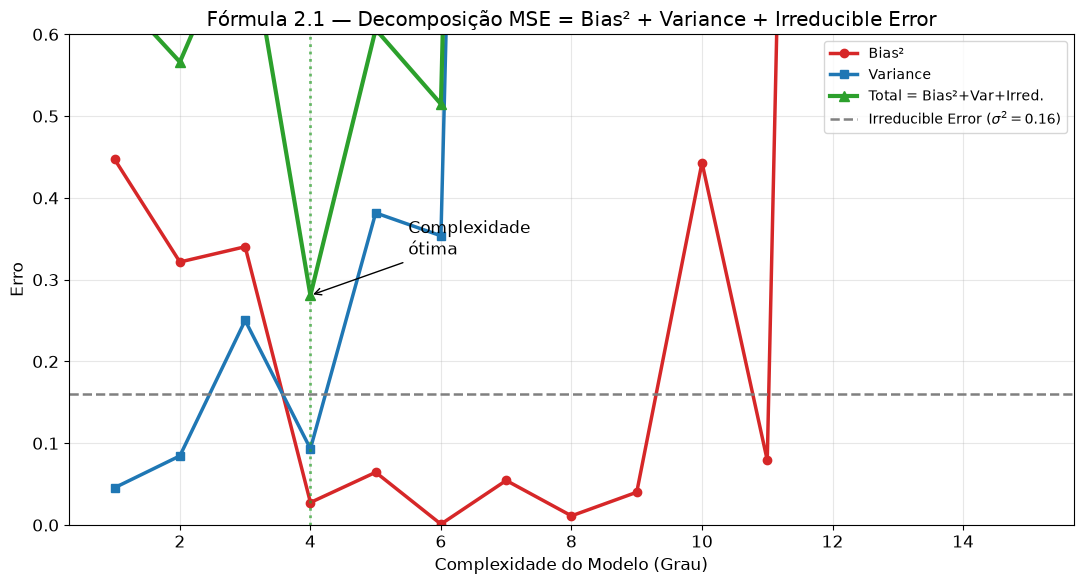

In [8]:
# Curva clássica do Bias-Variance Trade-Off
graus_all = list(range(1, 16))
b2s, vars_, tots = [], [], []
for g in graus_all:
    b2, v, ir, tot = estimar_decomposicao(g)
    b2s.append(b2); vars_.append(v); tots.append(tot)

plt.figure(figsize=(11, 6))
plt.plot(graus_all, b2s,  'tab:red',   lw=2.5, marker='o', ms=6, label='Bias²')
plt.plot(graus_all, vars_,'tab:blue',  lw=2.5, marker='s', ms=6, label='Variance')
plt.plot(graus_all, tots, 'tab:green', lw=3,   marker='^', ms=7, label='Total = Bias²+Var+Irred.')
plt.axhline(sigma_ruido**2, color='gray', ls='--', lw=1.8, label=f'Irreducible Error ($\\sigma^2={sigma_ruido**2:.2f}$)')
idx_min = np.argmin(tots)
plt.axvline(graus_all[idx_min], color='tab:green', ls=':', lw=2, alpha=0.7)
plt.annotate('Complexidade\nótima', xy=(graus_all[idx_min], tots[idx_min]),
             xytext=(graus_all[idx_min]+1.5, tots[idx_min]+0.05),
             arrowprops=dict(arrowstyle='->'))
plt.xlabel('Complexidade do Modelo (Grau)'); plt.ylabel('Erro')
plt.title('Fórmula 2.1 — Decomposição MSE = Bias² + Variance + Irreducible Error')
plt.legend(fontsize=10); plt.ylim(0, 0.6); plt.tight_layout(); plt.show()

---

## Fórmula 2.2 — Bias ao Quadrado

### A Fórmula

$$\boxed{\text{Bias}^2(x) = \left(f(x) - \mathbb{E}[\hat{f}(x)]\right)^2}$$

### Interpretação

- $f(x)$ = valor verdadeiro em $x$
- $\mathbb{E}[\hat{f}(x)]$ = **média das previsões do modelo** ao longo de muitos datasets diferentes amostrados da mesma distribuição
- O **Bias** mede quão longe, em média, o modelo erra **sistematicamente**

**Analogia:** um arqueiro que aponta sempre à esquerda do alvo tem **alto Bias** — não importa quantas flechas ele atire, a média delas vai estar longe do centro.

### Causa e remédio

- **Alta causa:** modelo muito simples para capturar a complexidade real de $f$
- **Sintoma:** curvas de aprendizado onde treino e validação convergem para um erro alto (ambos ruins)
- **Remédio:** aumentar a complexidade do modelo, adicionar mais features, usar basis functions mais ricas

---

## Fórmula 2.3 — Variance do Modelo

### A Fórmula

$$\boxed{\text{Variance}(x) = \mathbb{E}\!\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]}$$

### Interpretação

A Variance mede **quão sensível é o modelo às mudanças no dataset de treino**. Se treinar em dois datasets diferentes (amostrados da mesma população) produz modelos muito diferentes → alta Variance.

**Analogia:** um arqueiro com a mão tremida dispara flechas em posições aleatórias — a média pode estar no alvo, mas cada flecha individual erra muito.

### Causa e remédio

- **Alta causa:** modelo com muitos parâmetros livres (grau polinomial alto, rede neural profunda sem regularização)
- **Sintoma:** curva de aprendizado com **gap grande** entre treino e validação
- **Remédio:** regularização (Ridge, Lasso), mais dados, Ensembles (Bagging/Random Forest)

---

## Fórmula 2.4 — K-Fold Cross-Validation

### A Fórmula

$$\boxed{\text{CV}_{(K)} = \frac{1}{K} \sum_{k=1}^{K} \text{MSE}_k}$$

### Como funciona

1. Divida os dados em $K$ folds (partes) iguais
2. Para cada fold $k = 1, \ldots, K$:
   - Treine o modelo nos $K-1$ folds restantes
   - Calcule $\text{MSE}_k$ no fold $k$ (validação)
3. O erro de CV é a **média** dos $K$ erros

### Por que é usada?

- Estima o **erro de generalização real** sem contaminar o conjunto de teste
- Mais confiável do que um único split (Hold-Out), especialmente com poucos dados

| Variante | K | Quando usar |
|----------|---|-------------|
| **K-Fold** | 5 ou 10 | Padrão geral |
| **Stratified K-Fold** | 5 ou 10 | Classificação com classes desbalanceadas |
| **LOO (Leave-One-Out)** | $N$ | Datasets muito pequenos |
| **Hold-Out** | 1 | $N$ muito grande |

> **Regra de ouro:** nunca use o conjunto de teste para tomar decisões — nem para escolher $\lambda$, nem para comparar modelos.

---

# AULA 3 — Regularization Strategies & Cross-Validation

---

## Fórmula 3.1 — Loss Function Geral com Regularização (Soft Regularization)

### A Fórmula

$$\boxed{\mathcal{L}(\theta) = \underbrace{\frac{1}{N}\sum_{i=1}^{N}\|f_\theta(x_i) - y_i\|^2}_{\text{Data Fit (MSE)}} + \underbrace{\lambda \, \mathcal{R}(\theta)}_{\text{Penalidade}}}$$

| Símbolo | Significado |
|---------|-------------|
| $\theta$ | Parâmetros do modelo |
| $\mathcal{R}(\theta)$ | Funcional de regularização (L2, L1, etc.) |
| $\lambda \geq 0$ | **Hiperparâmetro de regularização** — força da penalidade |

### Efeito de $\lambda$

- $\lambda = 0$: sem penalidade → modelo original (risco de overfitting)
- $\lambda \to \infty$: apenas penalidade → $\theta \to 0$ (underfitting total)
- $\lambda$ ótimo: encontrado via **Cross-Validation em log-grid**

### Tipos de Regularização

| Tipo | Fórmula | Geometria |
|------|---------|----------|
| **Hard** | $\min \mathcal{L}$ s.t. $\theta \in C$ | Restrição estrita de conjunto |
| **Soft (Variacional)** | $\mathcal{L} + \lambda\mathcal{R}(\theta)$ | Penalidade adicionada à loss |
| **Output** | $\mathcal{L} + \mathcal{R}(y_i)$ | Penaliza propriedades da saída |

---

## Fórmula 3.2 — Ridge Regression (L2 Regularization)

### A Fórmula — Objetivo

$$\boxed{\hat{\theta}_{\text{Ridge}} = \arg\min_\theta \frac{1}{N}\sum_{i=1}^{N}\|f_\theta(x_i) - y_i\|^2 + \lambda\|\theta\|^2}$$

### A Fórmula — Solução Analítica Fechada

$$\boxed{\hat{\theta}_{\text{Ridge}} = (X^TX + \lambda I)^{-1}X^T\mathbf{y}}$$

### Por que é usada?

Comparando com a Normal Equation original $(X^TX)^{-1}X^T\mathbf{y}$:
- A Ridge adiciona $\lambda I$ à diagonal → **garante que a matriz é invertível** mesmo quando $X^TX$ é singular
- Isso acontece automaticamente quando $p > K$ (mais features que dados) ou quando colunas de $X$ são correlacionadas
- O efeito é **encolher todos os coeficientes em direção a zero**, mas raramente zerá-los exatamente

### Geometria

A restrição hard equivalente é uma **bola euclidiana** (círculo em 2D):
$$B_R^2 = \{\theta : \|\theta\| \leq R\}$$
O otimizador encontra o ponto dessa bola mais próximo do ótimo não-restrito $\theta^*$.

> **Nomes equivalentes:** Ridge (estatística) = Weight Decay (deep learning) = Tikhonov Regularization (matemática aplicada)

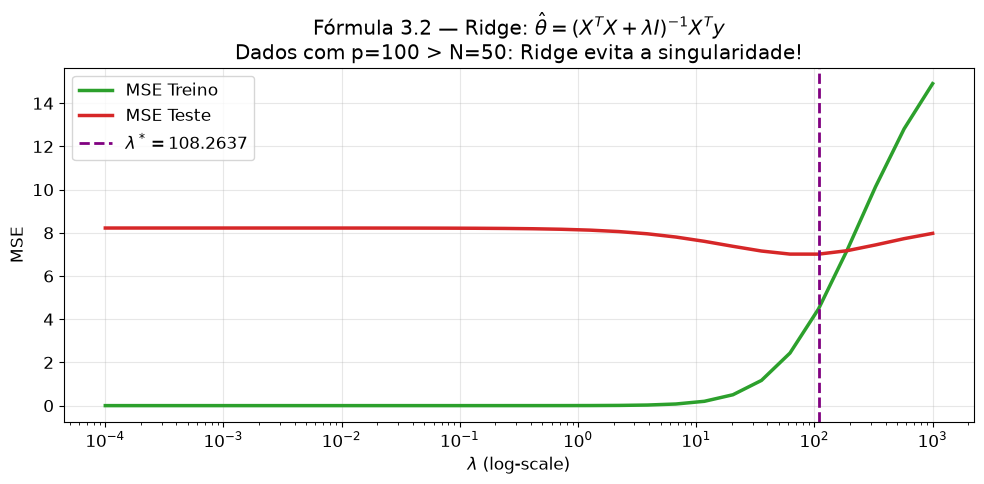

In [9]:
# Ridge: comparação de soluções com e sem regularização
np.random.seed(7)
N, p = 50, 100  # p > N: sem regularização, sistema singular!
X_hd = np.random.randn(N, p)
theta_real = np.zeros(p); theta_real[:5] = [3.0, -2.0, 1.5, -1.0, 0.8]
y_hd = X_hd @ theta_real + np.random.normal(0, 0.5, N)

lambdas = np.logspace(-4, 3, 30)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X_tr, X_te, y_tr, y_te = train_test_split(X_hd, y_hd, test_size=0.3, random_state=42)

mse_tr, mse_te = [], []
for lam in lambdas:
    # Solução Ridge: (XᵀX + λI)⁻¹ Xᵀy
    theta_ridge = np.linalg.solve(X_tr.T @ X_tr + lam * np.eye(p), X_tr.T @ y_tr)
    mse_tr.append(mean_squared_error(y_tr, X_tr @ theta_ridge))
    mse_te.append(mean_squared_error(y_te, X_te @ theta_ridge))

melhor_idx = np.argmin(mse_te)
plt.figure(figsize=(10, 5))
plt.semilogx(lambdas, mse_tr, 'tab:green', lw=2.5, label='MSE Treino')
plt.semilogx(lambdas, mse_te, 'tab:red',   lw=2.5, label='MSE Teste')
plt.axvline(lambdas[melhor_idx], color='purple', ls='--', lw=2,
            label=f'$\\lambda^*={lambdas[melhor_idx]:.4f}$')
plt.xlabel('$\\lambda$ (log-scale)'); plt.ylabel('MSE')
plt.title('Fórmula 3.2 — Ridge: $\\hat{{\\theta}} = (X^TX + \\lambda I)^{-1}X^Ty$\n'
          f'Dados com p={p} > N={N}: Ridge evita a singularidade!')
plt.legend(); plt.tight_layout(); plt.show()

---

## Fórmula 3.3 — Lasso (L1 Regularization)

### A Fórmula

$$\boxed{\hat{\theta}_{\text{Lasso}} = \arg\min_\theta \frac{1}{N}\sum_{i=1}^{N}\|f_\theta(x_i) - y_i\|^2 + \lambda\|\theta\|_1}$$

onde $\|\theta\|_1 = \sum_{j=1}^{d}|\theta_j|$.

### Por que o Lasso produz esparsidade?

A região viável da Hard L1 é um **diamante** (octaedro em $d$ dimensões). Os **vértices** do diamante estão nos eixos coordenados — onde $\theta_j = 0$ para todos exceto um $j$. As curvas de nível da Loss Function tendem a tocar o diamante **nesses vértices**, forçando coeficientes exatamente a zero!

| Método | Penalidade | Geometria | Esparsidade? |
|--------|-----------|-----------|-------------|
| **Ridge (L2)** | $\lambda\|\theta\|^2$ | Bola (círculo) | ❌ Raramente |
| **Lasso (L1)** | $\lambda\|\theta\|_1$ | Diamante | ✅ Sim, exata |
| **Elastic Net** | $\lambda_1\|\theta\|_1 + \lambda_2\|\theta\|^2$ | Híbrido | ✅ Sim |

### Por que L0 não é usada diretamente?

A pseudo-norma L0 conta o número de parâmetros não-zero:
$$\|\theta\|_0 = \#\{j : \theta_j \neq 0\}$$

Problemas:
1. **Não é convexa** → espaço de busca não-convexo, com mínimos locais
2. **Não é diferenciável** → gradiente não existe
3. **NP-hard** → requer enumerar $\binom{p}{s}$ subconjuntos de features

**O Lasso é a convexificação elegante do L0** — o menor relaxamento convexo que ainda induz esparsidade.

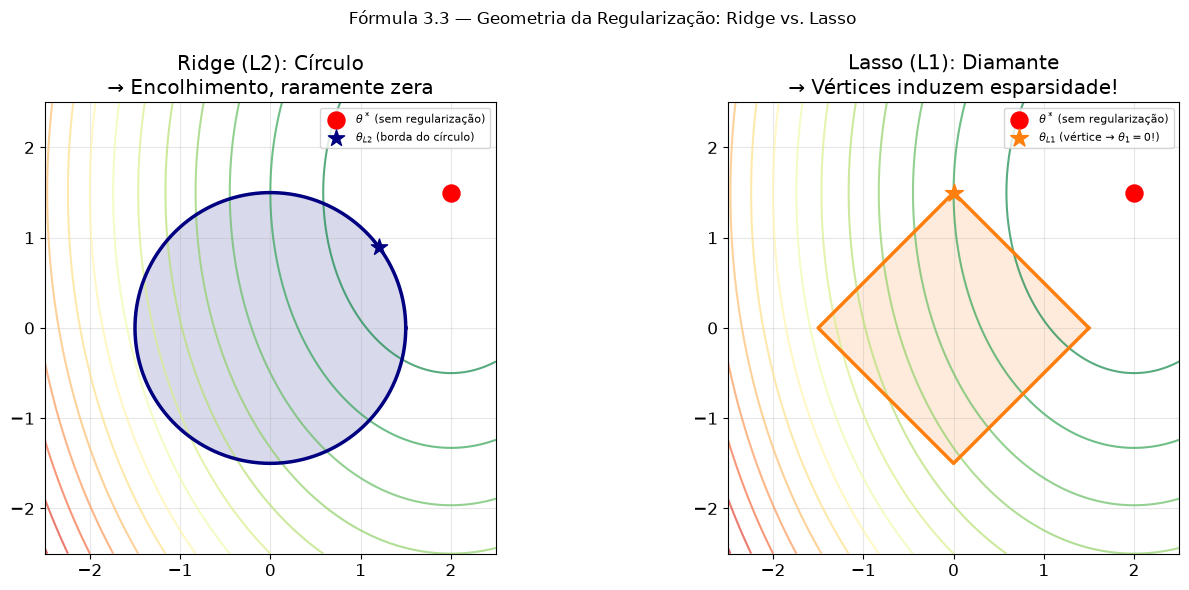

In [10]:
# Visualização geométrica: círculo (L2) vs. diamante (L1)
from sklearn.linear_model import Ridge as RidgeSK, Lasso as LassoSK

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
T1, T2 = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.5, 2.5, 300))
Loss = (T1 - 2.0)**2 + 0.5*(T2 - 1.5)**2

# L2 — círculo
ax = axes[0]
ax.contour(T1, T2, Loss, levels=15, cmap='RdYlGn_r', alpha=0.7)
R = 1.5
th = np.linspace(0, 2*np.pi, 300)
ax.fill(R*np.cos(th), R*np.sin(th), alpha=0.15, color='navy')
ax.plot(R*np.cos(th), R*np.sin(th), 'navy', lw=2.5)
ax.scatter([2.0],[1.5], s=150, color='red', zorder=7, label='$\\theta^*$ (sem regularização)')
theta_l2 = np.array([2.0,1.5]) * R/np.sqrt(2.0**2+1.5**2)
ax.scatter(*theta_l2, s=150, color='navy', marker='*', zorder=7, label='$\\theta_{L2}$ (borda do círculo)')
ax.set_title('Ridge (L2): Círculo\n→ Encolhimento, raramente zera')
ax.legend(fontsize=8); ax.set_aspect('equal')

# L1 — diamante
ax = axes[1]
ax.contour(T1, T2, Loss, levels=15, cmap='RdYlGn_r', alpha=0.7)
diamond_x = [R, 0, -R, 0, R]; diamond_y = [0, R, 0, -R, 0]
ax.fill(diamond_x, diamond_y, alpha=0.15, color='tab:orange')
ax.plot(diamond_x, diamond_y, 'tab:orange', lw=2.5)
ax.scatter([2.0],[1.5], s=150, color='red', zorder=7, label='$\\theta^*$ (sem regularização)')
ax.scatter([0],[R], s=180, color='tab:orange', marker='*', zorder=7,
           label='$\\theta_{L1}$ (vértice → $\\theta_1=0$!)')
ax.set_title('Lasso (L1): Diamante\n→ Vértices induzem esparsidade!')
ax.legend(fontsize=8); ax.set_aspect('equal')

plt.suptitle('Fórmula 3.3 — Geometria da Regularização: Ridge vs. Lasso', fontsize=12)
plt.tight_layout(); plt.show()

---

## Fórmula 3.4 — Elastic Net

### A Fórmula

$$\boxed{\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\|f_\theta(x_i) - y_i\|^2 + \lambda_1\|\theta\|_1 + \lambda_2\|\theta\|^2}$$

### Por que é usada?

Quando features são **correlacionadas entre si**, o Lasso seleciona arbitrariamente uma delas (instabilidade). O Elastic Net combina L1 e L2:
- **L1** → produz esparsidade (elimina features irrelevantes)
- **L2** → estabiliza a seleção quando features são correlacionadas (seleciona **grupos**)

O parâmetro `l1_ratio` no sklearn controla a mistura: $0$ = puro L2, $1$ = puro L1.

---

## Fórmula 3.5 — Early Stopping ≈ L2 Regularization

### A Relação

Para modelos lineares otimizados com Gradient Descent com taxa $\eta$ e $t$ iterações:

$$\boxed{\hat{\theta}_{\text{Early Stop}}(t) \approx \hat{\theta}_{\text{Ridge}}\!\left(\lambda = \frac{1}{\eta t}\right)}$$

### Por que é importante?

Parar o treinamento cedo é **matematicamente equivalente** a aplicar Ridge com $\lambda = 1/(\eta t)$:
- Mais iterações → $t$ aumenta → $\lambda$ efetivo diminui → menos regularização
- Parar cedo → $t$ pequeno → $\lambda$ efetivo grande → mais regularização

**Vantagem prática:** Early Stopping não precisa de grid search explícito para $\lambda$ — basta monitorar o erro de validação e parar quando ele para de diminuir.

### Como implementar

1. Avalie o erro de **validação** a cada época
2. Se o erro de validação não melhora por `patience` épocas → **pare**
3. Restaure os pesos do **melhor checkpoint** (não do último)

---

## Fórmula 3.6 — Dropout

### A Fórmula

Durante o **treino** (máscara aleatória):

$$\boxed{\tilde{h}_j = m_j \cdot h_j, \quad m_j \sim \text{Bernoulli}(1-p)}$$

Durante a **inferência** (escala compensatória):

$$h_j^{\text{test}} = (1-p) \cdot h_j$$

| Símbolo | Significado |
|---------|-------------|
| $h_j$ | Ativação do neurônio $j$ |
| $m_j$ | Máscara binária aleatória |
| $p$ | Taxa de dropout (fração de neurônios zerados) |

### Por que é usada?

Com $d$ neurônios e taxa $p$, existem $2^d$ sub-redes possíveis. O Dropout treina implicitamente uma **média exponencial de modelos** — é um **Ensemble implícito** sem o custo de treinar cada modelo separadamente.

O fator $(1-p)$ na inferência compensa o fato de que durante o treino, em média, apenas $(1-p)d$ neurônios estão ativos.

Taxa típica: $p \in [0.1, 0.5]$

---

## Fórmula 3.7 — Label Smoothing (Output Regularization)

### A Fórmula

$$\boxed{y_k^{\text{smooth}} = y_k (1 - \epsilon) + \frac{\epsilon}{K}}$$

| Símbolo | Significado |
|---------|-------------|
| $y_k$ | Label original (0 ou 1 para classe $k$) |
| $\epsilon$ | Parâmetro de suavização ($\in [0.05, 0.2]$) |
| $K$ | Número total de classes |

### Exemplo com $K=5$ classes e $\epsilon=0.1$:

| | Classe 0 | Classe 1 | Classe 2 | Classe 3 | Classe 4 |
|-|----------|----------|----------|----------|----------|
| **Hard label** | 1.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **Smooth label** | 0.920 | 0.020 | 0.020 | 0.020 | 0.020 |

### Por que é usada?

Labels binários (one-hot) incentivam o modelo a ser **superconfiante** — probabilidades próximas de 1.0 causam overfitting. O Label Smoothing penaliza esse comportamento, levando a previsões mais calibradas. Muito usado em transformers e classificação de imagens.

---

# AULA 4 — Visão Probabilística & Regularização Bayesiana

---

## Fórmula 4.1 — Likelihood (Verossimilhança)

### A Fórmula

Assumindo ruído Gaussiano independente por amostra:

$$\boxed{p(\mathcal{D} \mid \theta) = \prod_{i=1}^{N} \exp\!\left(-\|f_\theta(x_i) - y_i\|^2\right)}$$

Tomando o logaritmo negativo:

$$-\log p(\mathcal{D} \mid \theta) = \sum_{i=1}^{N}\|f_\theta(x_i) - y_i\|^2 = \text{SSE} \propto \text{MSE}$$

### Insight fundamental

**O MSE não é arbitrário!** Ele emerge diretamente da suposição de que o ruído tem distribuição Gaussiana. Minimizar o MSE é equivalente a **maximizar a verossimilhança** (MLE — Maximum Likelihood Estimation) sob ruído gaussiano.

| Distribuição do ruído | Loss correspondente |
|----------------------|---------------------|
| Gaussiana | MSE (quadrático) |
| Laplace | MAE (valor absoluto) |
| Bernoulli | Cross-Entropy (binária) |
| Categórica | Cross-Entropy (multiclasse) |

---

## Fórmula 4.2 — Teorema de Bayes aplicado a Parâmetros

### A Fórmula

$$\boxed{p(\theta \mid \mathcal{D}) \propto p(\mathcal{D} \mid \theta) \cdot p(\theta)}$$

| Termo | Nome | Papel |
|-------|------|-------|
| $p(\mathcal{D} \mid \theta)$ | **Likelihood** | Quão prováveis são os dados dado o modelo? |
| $p(\theta)$ | **Prior** | Crença sobre os parâmetros antes de ver os dados |
| $p(\theta \mid \mathcal{D})$ | **Posterior** | Crença atualizada após observar os dados |

### Conexão com otimização

Maximizar o posterior = minimizar o negativo do log-posterior:

$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta \log p(\theta \mid \mathcal{D}) = \arg\min_\theta \left[-\log p(\mathcal{D} \mid \theta) - \log p(\theta)\right]$$

$$= \arg\min_\theta \underbrace{\text{MSE}(\theta)}_{-\log\text{ Likelihood}} + \underbrace{\lambda\mathcal{R}(\theta)}_{-\log\text{ Prior}}$$

**A regularização é secretamente um Prior Bayesiano sobre os parâmetros!**

---

## Fórmula 4.3 — MAP com Gaussian Prior → Ridge (L2)

### A Fórmula — Prior

$$\boxed{p(\theta) = \mathcal{N}(0, \tau^2 I) = \prod_{j=1}^{d} \frac{1}{\sqrt{2\pi\tau^2}} \exp\!\left(-\frac{\theta_j^2}{2\tau^2}\right)}$$

### Derivação: Gaussian Prior → L2

$$-\log p(\theta) = \frac{1}{2\tau^2}\sum_{j=1}^{d}\theta_j^2 + \text{const} = \frac{1}{2\tau^2}\|\theta\|^2 + \text{const}$$

O objetivo MAP completo:

$$\hat{\theta}_{\text{MAP}} = \arg\min_\theta \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - f_\theta(x_i))^2 + \frac{1}{2\tau^2}\|\theta\|^2$$

### A conexão

$$\boxed{\text{Gaussian Prior com } \tau^2 \equiv \text{Ridge com } \lambda = \frac{\sigma^2}{\tau^2}}$$

| $\tau^2$ grande (prior fraco) | $\tau^2$ pequeno (prior forte) |
|-------------------------------|-------------------------------|
| $\lambda$ pequeno → menos regularização | $\lambda$ grande → mais regularização |
| Crença de que $\theta$ pode ser qualquer valor | Crença forte de que $\theta \approx 0$ |

---

## Fórmula 4.4 — MAP com Laplace Prior → Lasso (L1)

### A Fórmula — Prior

$$\boxed{p(\theta) = \prod_{j=1}^{d} \frac{1}{2b} \exp\!\left(-\frac{|\theta_j|}{b}\right)}$$

### Derivação: Laplace Prior → L1

$$-\log p(\theta) = \frac{1}{b}\sum_{j=1}^{d}|\theta_j| + \text{const} = \frac{1}{b}\|\theta\|_1 + \text{const}$$

O objetivo MAP completo:

$$\hat{\theta}_{\text{MAP}} = \arg\min_\theta \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - f_\theta(x_i))^2 + \frac{1}{b}\|\theta\|_1$$

### A conexão

$$\boxed{\text{Laplace Prior com } b \equiv \text{Lasso com } \lambda = \frac{\sigma^2}{b}}$$

### Por que o Prior de Laplace produz esparsidade?

O Prior de Laplace tem um **pico pontiagudo em zero** — ele acredita *fortemente* que a maioria dos pesos deveria ser exatamente zero. Esta crença a priori se manifesta como esparsidade na solução MAP.

O Prior Gaussiano tem caudas mais pesadas perto de zero → coeficientes encolhem mas não zeram. O Prior de Laplace tem uma cúspide em zero → força coeficientes pequenos para exatamente zero.

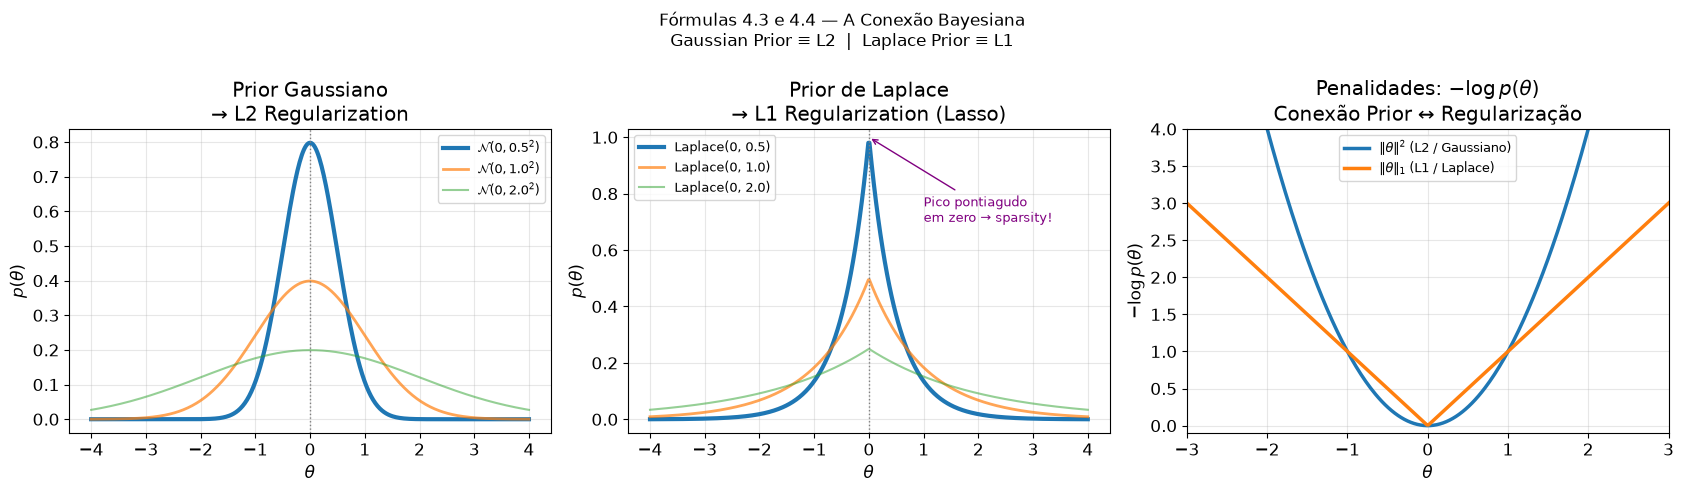

In [11]:
# Visualizando os priors e a conexão com as penalidades
theta_vis = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Prior Gaussiano
ax = axes[0]
for tau, lw_val, alpha_val in [(0.5, 3, 1.0), (1.0, 2, 0.7), (2.0, 1.5, 0.5)]:
    ax.plot(theta_vis, norm.pdf(theta_vis, 0, tau), lw=lw_val, alpha=alpha_val,
            label=f'$\\mathcal{{N}}(0, {tau}^2)$')
ax.set_title('Prior Gaussiano\n→ L2 Regularization')
ax.set_xlabel('$\\theta$'); ax.set_ylabel('$p(\\theta)$')
ax.legend(fontsize=9); ax.axvline(0, color='gray', ls=':', lw=1)

# Prior de Laplace
ax = axes[1]
for b, lw_val, alpha_val in [(0.5, 3, 1.0), (1.0, 2, 0.7), (2.0, 1.5, 0.5)]:
    ax.plot(theta_vis, laplace.pdf(theta_vis, 0, b), lw=lw_val, alpha=alpha_val,
            label=f'Laplace(0, {b})')
ax.set_title('Prior de Laplace\n→ L1 Regularization (Lasso)')
ax.set_xlabel('$\\theta$'); ax.set_ylabel('$p(\\theta)$')
ax.legend(fontsize=9); ax.axvline(0, color='gray', ls=':', lw=1)
ax.annotate('Pico pontiagudo\nem zero → sparsity!',
            xy=(0, laplace.pdf(0, 0, 0.5)), xytext=(1.0, 0.7),
            arrowprops=dict(arrowstyle='->', color='purple'), color='purple', fontsize=9)

# Penalidades: -log p(θ)
ax = axes[2]
ax.plot(theta_vis, theta_vis**2, 'tab:blue', lw=2.5, label='$\\|\\theta\\|^2$ (L2 / Gaussiano)')
ax.plot(theta_vis, np.abs(theta_vis), 'tab:orange', lw=2.5, label='$\\|\\theta\\|_1$ (L1 / Laplace)')
ax.set_xlim(-3, 3); ax.set_ylim(-0.1, 4)
ax.set_title('Penalidades: $-\\log p(\\theta)$\nConexão Prior ↔ Regularização')
ax.set_xlabel('$\\theta$'); ax.set_ylabel('$-\\log p(\\theta)$')
ax.legend(fontsize=9)

plt.suptitle('Fórmulas 4.3 e 4.4 — A Conexão Bayesiana\nGaussian Prior ≡ L2  |  Laplace Prior ≡ L1', fontsize=12)
plt.tight_layout(); plt.show()

---

## Fórmula 4.5 — Bootstrap: Intervalo de Confiança por Percentil

### O Algoritmo

```
Input: dados D = {z₁, …, zN}, estatística S, replicatas B

for b = 1, …, B:
    Dᵇ ← amostrar N observações de D COM REPOSIÇÃO
    sᵇ ← S(Dᵇ)
end

Distribuição bootstrap: {s¹, …, sᴮ}
```

### A Fórmula — IC por Percentil (95%)

$$\boxed{\text{IC}_{95\%} = \left[\theta^*_{(\alpha/2)}, \; \theta^*_{(1-\alpha/2)}\right] = \left[q_{2.5\%}(\{s^b\}), \; q_{97.5\%}(\{s^b\})\right]}$$

### Por que é usada?

O Bootstrap estima a incerteza de um estimador **sem precisar de fórmulas analíticas**. A ideia central: tratar o dataset observado como uma **população empírica** e reamostrar dele com reposição para simular o processo de coletar novos datasets.

| Tipo de IC | Fórmula | Quando usar |
|------------|---------|-------------|
| **Normal** | $\hat{s} \pm 1.96 \cdot \text{std}(\{s^b\})$ | Distribuição aprox. Normal |
| **Percentil** | $[q_{2.5\%}, q_{97.5\%}]$ | Distribuição assimétrica |
| **BCa** | Corrige viés e aceleração | Mais preciso, mais complexo |

### Aplicação ao ML: Bagging

**Bagging** (Bootstrap Aggregating) = treinar o modelo em $B$ amostras bootstrap e **fazer a média das previsões**:

$$\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B}\hat{f}^b(x)$$

Resultado: **reduz a Variance** sem aumentar o Bias — é a base do Random Forest.

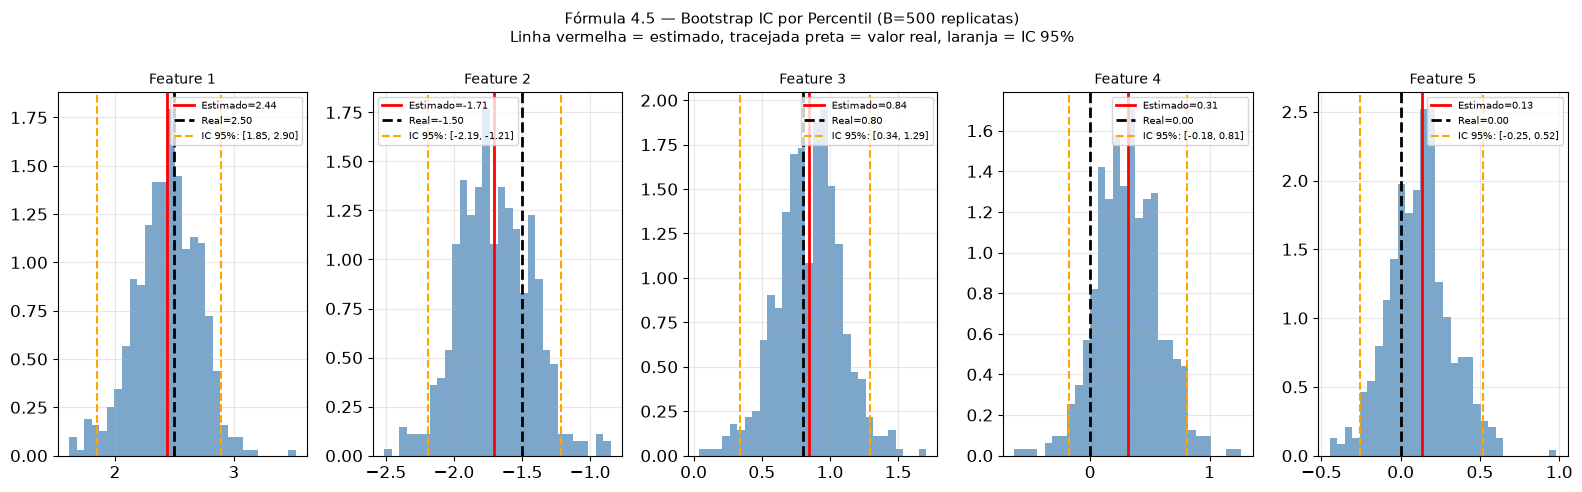

In [12]:
# Bootstrap: estimando incerteza de um coeficiente
from sklearn.linear_model import Ridge as RidgeSK
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
N_boot, p_boot = 80, 5
X_boot = StandardScaler().fit_transform(np.random.randn(N_boot, p_boot))
theta_real_b = np.array([2.5, -1.5, 0.8, 0.0, 0.0])
y_boot = X_boot @ theta_real_b + np.random.normal(0, 2.0, N_boot)

B = 500
coefs_boot = np.zeros((B, p_boot))
for b in range(B):
    idx = np.random.choice(N_boot, size=N_boot, replace=True)  # COM REPOSIÇÃO
    RidgeSK(alpha=1.0).fit(X_boot[idx], y_boot[idx]).coef_
    coefs_boot[b] = RidgeSK(alpha=1.0).fit(X_boot[idx], y_boot[idx]).coef_

coefs_orig = RidgeSK(alpha=1.0).fit(X_boot, y_boot).coef_

fig, axes = plt.subplots(1, p_boot, figsize=(16, 5), sharey=False)
for j, ax in enumerate(axes):
    ax.hist(coefs_boot[:, j], bins=30, color='steelblue', alpha=0.7, density=True)
    ci_lo = np.percentile(coefs_boot[:, j], 2.5)
    ci_hi = np.percentile(coefs_boot[:, j], 97.5)
    ax.axvline(coefs_orig[j], color='red',    lw=2, label=f'Estimado={coefs_orig[j]:.2f}')
    ax.axvline(theta_real_b[j], color='black', lw=2, ls='--', label=f'Real={theta_real_b[j]:.2f}')
    ax.axvline(ci_lo, color='orange', ls='--', lw=1.5)
    ax.axvline(ci_hi, color='orange', ls='--', lw=1.5, label=f'IC 95%: [{ci_lo:.2f}, {ci_hi:.2f}]')
    ax.set_title(f'Feature {j+1}', fontsize=10); ax.legend(fontsize=7)

plt.suptitle('Fórmula 4.5 — Bootstrap IC por Percentil (B=500 replicatas)\n'
             'Linha vermelha = estimado, tracejada preta = valor real, laranja = IC 95%', fontsize=11)
plt.tight_layout(); plt.show()

---

# OTIMIZAÇÃO — Métodos de Primeira e Segunda Ordem

*Baseado no Capítulo de Otimização: Statistisches_Lernen_2_v4.pdf*

O aprendizado de máquina é fundamentalmente um problema de **minimização de uma função de perda**:
$$\hat{\theta} = \arg\min_{\theta} f(\theta), \quad f(\theta) = \frac{1}{N}\sum_{i=1}^{N}\ell(f_\theta(x_i), y_i) + \lambda\mathcal{R}(\theta)$$

Esta seção cobre todos os métodos de otimização apresentados na aula, do Gradient Descent clássico até os otimizadores adaptativos modernos (Adam, AdaGrad) e métodos de segunda ordem (Newton, L-BFGS).

---

## Fórmula OPT.1 — Convexidade

### A Definição

Uma função $f: \mathbb{R}^d \to \mathbb{R}$ é **convexa** se, para todo $\alpha, \beta \in \mathbb{R}^d$ e todo $\lambda \in [0,1]$:

$$\boxed{f(\lambda\alpha + (1-\lambda)\beta) \leq \lambda f(\alpha) + (1-\lambda)f(\beta)}$$

**Geometricamente:** a linha que conecta dois pontos quaisquer do gráfico de $f$ está sempre **acima ou sobre** o gráfico.

### Por que importa para otimização?

| Função convexa | Função não-convexa |
|---------------|--------------------|
| Qualquer mínimo local é **global** | Mínimos locais ≠ mínimo global |
| Gradient Descent converge para o ótimo | GD pode ficar preso em mínimos locais |
| Garantias teóricas de convergência | Otimização é NP-hard em geral |

### Funções convexas comuns em ML

| Função | É convexa? |
|--------|------------|
| MSE (regressão linear) | ✅ Sim |
| Ridge: $\text{MSE} + \lambda\|\theta\|^2$ | ✅ Sim |
| Lasso: $\text{MSE} + \lambda\|\theta\|_1$ | ✅ Sim |
| Redes neurais profundas | ❌ Não em geral |

> **Insight prático:** em redes neurais sobredimensionadas a maioria dos mínimos locais tem perda similar ao global. O problema real são **regiões de sela**, das quais o SGD com ruído ajuda a escapar.

## Fórmula OPT.2 — Gradient Descent (Batch)

### A Fórmula

$$\boxed{\theta_{t+1} = \theta_t - \eta_t \nabla f(\theta_t)}$$

| Símbolo | Significado |
|---------|-------------|
| $\theta_t$ | Parâmetros na iteração $t$ |
| $\eta_t > 0$ | **Learning rate** — tamanho do passo |
| $\nabla f(\theta_t)$ | Gradiente da loss — direção de maior crescimento |
| $-\nabla f(\theta_t)$ | **Direção de descida** — move-se para minimizar $f$ |

### Dedução Intuitiva

Pela expansão de Taylor de 1ª ordem:
$$f(\theta_{t+1}) \approx f(\theta_t) - \eta_t \|\nabla f(\theta_t)\|^2 < f(\theta_t)$$

(válido para $\eta_t$ suficientemente pequeno)

### Estratégias de Learning Rate

| Estratégia | Fórmula | Quando usar |
|------------|---------|-------------|
| **Fixo** | $\eta_t = \eta$ | Simples, pode divergir ou convergir lento |
| **Step Decay** | $\eta_t = \eta_0 \cdot \gamma^{\lfloor t/k \rfloor}$ | Reduzir após $k$ épocas |
| **Cosine Decay** | $\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_0-\eta_{\min})(1+\cos(\pi t/T))$ | Estado da arte |
| **Line Search** | Armijo / Wolfe conditions | Problemas convexos |

> **Custo:** cada iteração processa **todos os $N$ dados** — caro para datasets grandes. Solução: SGD com minibatch (OPT.5).

## Fórmula OPT.3 — Momentum

### A Fórmula

$$\boxed{v_{t+1} = \beta v_t + \nabla f(\theta_t), \qquad \theta_{t+1} = \theta_t - \eta_t v_{t+1}}$$

| Símbolo | Significado |
|---------|-------------|
| $v_t$ | **Velocity** — acumulado ponderado dos gradientes passados |
| $\beta$ | Fator de momentum ($\approx 0.9$ típico) |

### Intuição Física

Uma bola rolando em um vale: sem momentum ela muda de direção bruscamente. Com momentum **acumula velocidade** nas direções consistentes e **amorte oscilações** transversais.

Expandindo: $v_{t+1} = \nabla f(\theta_t) + \beta \nabla f(\theta_{t-1}) + \beta^2 \nabla f(\theta_{t-2}) + \ldots$ → **EMA dos gradientes**.

### Por que é usado?

1. **Acelera a convergência** em vales estreitos e longos
2. **Amorte oscilações** em direções com alta curvatura
3. Pode escapar de mínimos locais rasos por inércia

---

## Fórmula OPT.4 — Nesterov Acceleration

$$\boxed{v_{t+1} = \beta v_t + \nabla f(\theta_t - \eta\beta v_t), \qquad \theta_{t+1} = \theta_t - \eta v_{t+1}}$$

O gradiente é calculado na **posição projetada** $\theta_t - \eta\beta v_t$ (onde chegaríamos com o passo de momentum), não na posição atual.

> **Intuição:** "olhar adiante antes de calcular o gradiente" — evita overshooting. Tem garantias de convergência melhores que o Momentum clássico para funções convexas suaves.

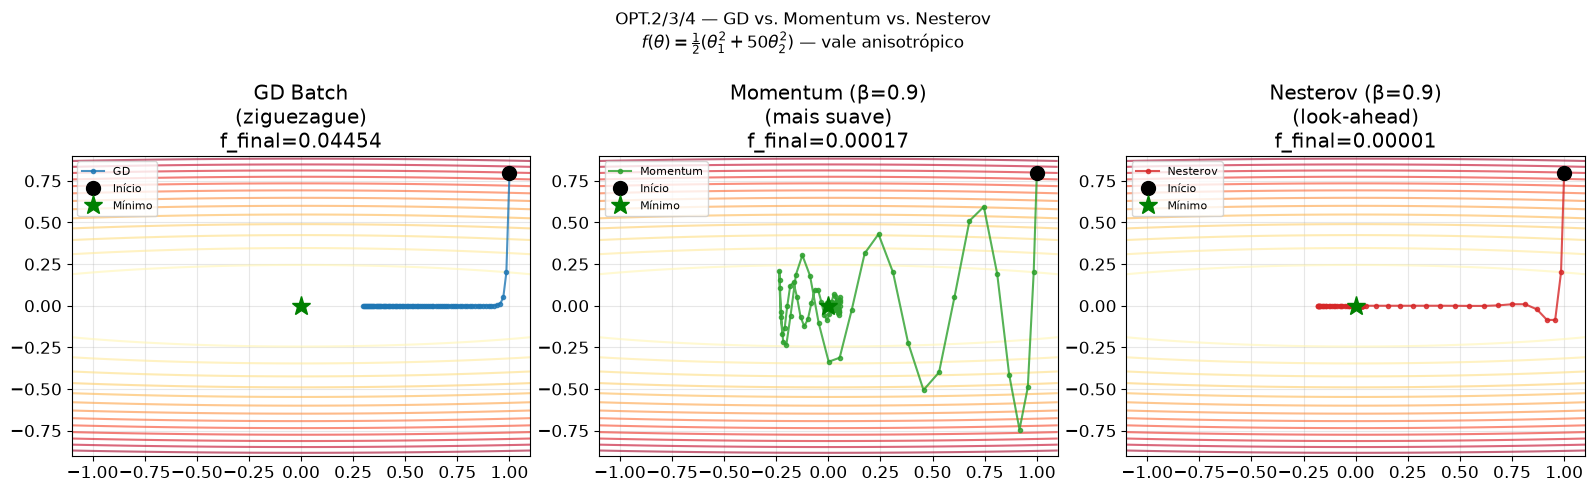

GD final:       f = 0.044542,  θ = [2.98468457e-01 5.47382213e-49]
Momentum final: f = 0.000172,  θ = [-0.01254214  0.00193421]
Nesterov final: f = 0.000012,  θ = [-4.91172154e-03 -4.07087285e-27]


In [13]:
# GD vs. Momentum vs. Nesterov em vale anisotrópico (f = 0.5*(θ₁² + 50θ₂²))
import numpy as np
import matplotlib.pyplot as plt

def f_aniso(theta): return 0.5*(theta[0]**2 + 50*theta[1]**2)
def grad_aniso(theta): return np.array([theta[0], 50*theta[1]])

def run_gd(theta0, eta, n):
    path = [theta0.copy()]; theta = theta0.copy()
    for _ in range(n):
        theta = theta - eta * grad_aniso(theta)
        path.append(theta.copy())
    return np.array(path)

def run_momentum_aniso(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_aniso(theta)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

def run_nesterov(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_aniso(theta - eta * beta * v)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

theta0 = np.array([1.0, 0.8])
n_steps = 80

p_gd  = run_gd(theta0, eta=0.015, n=n_steps)
p_mom = run_momentum_aniso(theta0, eta=0.015, beta=0.9, n=n_steps)
p_nes = run_nesterov(theta0, eta=0.015, beta=0.9, n=n_steps)

T1, T2 = np.meshgrid(np.linspace(-1.1, 1.1, 200), np.linspace(-0.9, 0.9, 200))
Z = 0.5*(T1**2 + 50*T2**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, path, title, color, label in zip(
    axes,
    [p_gd, p_mom, p_nes],
    ['GD Batch\n(ziguezague)', 'Momentum (β=0.9)\n(mais suave)', 'Nesterov (β=0.9)\n(look-ahead)'],
    ['tab:blue', 'tab:green', 'tab:red'],
    ['GD', 'Momentum', 'Nesterov']
):
    ax.contour(T1, T2, Z, levels=18, cmap='YlOrRd', alpha=0.6)
    ax.plot(path[:,0], path[:,1], '-o', color=color, ms=3, lw=1.5, alpha=0.8, label=label)
    ax.plot(*theta0, 'ko', ms=10, zorder=5, label='Início')
    ax.plot(0, 0, 'g*', ms=14, zorder=5, label='Mínimo')
    ax.set_title(f'{title}\nf_final={f_aniso(path[-1]):.5f}')
    ax.legend(fontsize=8); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-0.9, 0.9)

plt.suptitle('OPT.2/3/4 — GD vs. Momentum vs. Nesterov\n'
             '$f(\\theta) = \\frac{1}{2}(\\theta_1^2 + 50\\theta_2^2)$ — vale anisotrópico', fontsize=12)
plt.tight_layout(); plt.show()

print(f"GD final:       f = {f_aniso(p_gd[-1]):.6f},  θ = {p_gd[-1]}")
print(f"Momentum final: f = {f_aniso(p_mom[-1]):.6f},  θ = {p_mom[-1]}")
print(f"Nesterov final: f = {f_aniso(p_nes[-1]):.6f},  θ = {p_nes[-1]}")

## Fórmula OPT.5 — Stochastic Gradient Descent (SGD) com Minibatch

### A Fórmula

Em vez do gradiente completo, usa um **gradiente estimado sobre um minibatch** $B$:

$$\nabla \ell_B(\theta_t) = \frac{1}{|B|} \sum_{z \in B} \nabla \ell(\theta_t; z)$$

$$\boxed{\theta_{t+1} = \theta_t - \eta_t \nabla \ell_B(\theta_t)}$$

### Pseudocódigo SGD

```
Input: dataset D, loss ℓ, θ₀, learning rates ηₜ, batch size m

for epoch = 1, 2, ...:
    shuffle D                              ← embaralhar evita bias sistemático
    for each minibatch B of size m:
        g = (1/|B|) Σ_{z in B} ∇ℓ(θ; z)  ← gradiente do minibatch
        θ = θ - ηₜ g                       ← atualização
    end
end
```

### Casos Especiais

| Variante | Tamanho do batch | Alias |
|----------|-----------------|-------|
| **Full-batch GD** | $|B| = N$ (todos os dados) | "Gradient Descent" clássico |
| **Mini-batch SGD** | $|B| \in [32, 512]$ | "SGD" na prática |
| **Online SGD** | $|B| = 1$ | Stochastic GD original |

### Escolhas Práticas

| Hiperparâmetro | Efeito | Guia Típico |
|----------------|--------|-------------|
| **Batch size** | Controla ruído e eficiência no hardware | Potências de 2; batches maiores → learning rates maiores |
| **Learning rate decay** | Reduz ruído perto do ótimo | Cosine ou step decay — usar curvas de validação |
| **Shuffling** | Evita bias sistemático | Embaralhar a cada época |
| **Early stopping** | Age como regularização | Monitorar loss de validação, não só de treino |

### Por que o ruído pode ser útil?

O gradiente de minibatch é um **estimador não-viesado** do gradiente completo:
$$\mathbb{E}_B[\nabla \ell_B(\theta)] = \nabla f(\theta)$$

O ruído com variância $\propto \sigma^2/|B|$ pode ajudar a **escapar de mínimos locais rasos e regiões de sela** — motivo pelo qual SGD é o método dominante para treinar redes neurais em larga escala.

## Fórmula OPT.6 — AdaGrad (Adaptive Gradient)

### A Fórmula

$$g_t = \nabla_\theta \ell_{B_t}(\theta_{t-1}), \qquad G_t = G_{t-1} + g_t \odot g_t$$

$$\boxed{\theta_t = \theta_{t-1} - \eta \frac{g_t}{\sqrt{G_t + \varepsilon}}}$$

Forma explícita por coordenada $i$:
$$\theta_{t,i} = \theta_{t-1,i} - \eta \frac{g_{t,i}}{\sqrt{G_{t,i} + \varepsilon}}$$

| Símbolo | Significado |
|---------|-------------|
| $G_t$ | **Soma acumulada** dos quadrados dos gradientes (por coordenada) |
| $\odot$ | Produto elemento a elemento (Hadamard) |
| $\varepsilon$ | Constante de estabilidade numérica ($\approx 10^{-8}$) |
| $\eta / \sqrt{G_{t,i}}$ | Learning rate efetivo para a coordenada $i$ |

### Intuição

AdaGrad é um **pré-condicionador diagonal**: rescala cada coordenada pela magnitude histórica dos seus gradientes.

- **Coordenadas com gradientes grandes/frequentes** → $G_{t,i}$ cresce → passos menores
- **Features raras/esparsas** → $G_{t,i}$ pequeno → passos maiores → aprendizado mais agressivo onde os dados são escassos

### Quando funciona bem / Limitação

✅ Problemas **esparsos** de alta dimensão (NLP, features de texto, sistemas de recomendação)

❌ **Learning rates só decrescem** — após muitas iterações, os passos ficam minúsculos e o modelo para de aprender. → AdaDelta e Adam corrigem este problema.

## Fórmula OPT.7 — AdaDelta (Windowed Adaptation)

### A Fórmula

$$\mathbb{E}[g^2]_t = \rho \,\mathbb{E}[g^2]_{t-1} + (1-\rho)\, g_t^2$$

$$\text{RMS}[g]_t = \sqrt{\mathbb{E}[g^2]_t + \varepsilon}, \qquad \text{RMS}[\Delta\theta]_t = \sqrt{\mathbb{E}[\Delta\theta^2]_t + \varepsilon}$$

$$\boxed{\Delta\theta_t = -\frac{\text{RMS}[\Delta\theta]_{t-1}}{\text{RMS}[g]_t}\, g_t, \qquad \theta_t = \theta_{t-1} + \Delta\theta_t}$$

$$\mathbb{E}[\Delta\theta^2]_t = \rho\, \mathbb{E}[\Delta\theta^2]_{t-1} + (1-\rho)\,\Delta\theta_t^2$$

| Símbolo | Significado |
|---------|-------------|
| $\rho$ | Fator de decaimento EMA ($\approx 0.95$ típico) |
| $\mathbb{E}[g^2]_t$ | EMA dos gradientes ao quadrado |
| $\mathbb{E}[\Delta\theta^2]_t$ | EMA das atualizações ao quadrado |
| $\text{RMS}[\cdot]$ | Root Mean Square — raiz do segundo momento |

### O que muda em relação ao AdaGrad?

| AdaGrad | AdaDelta |
|---------|---------|
| Acumula **soma** de $g^2$ (cresce sempre) | Usa **EMA** de $g^2$ (esquece gradientes antigos) |
| Learning rate só decresce | Learning rate pode se recuperar |
| Requer learning rate global $\eta$ | Forma original **não** precisa de $\eta$ |

> **Mensagem chave:** AdaDelta corrige o problema do AdaGrad de passos monotonicamente decrescentes usando uma janela deslizante de gradientes recentes. $\rho \approx 0.95$ é o típico (memória longa).

## Fórmula OPT.8 — Adam (Adaptive Moment Estimation)

### A Fórmula

$$g_t = \nabla_\theta \ell_{B_t}(\theta_{t-1})$$

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \quad \text{(1º momento — EMA do gradiente)}$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 \quad \text{(2º momento — EMA do gradiente²)}$$

**Correção de viés** (compensa $m_0 = v_0 = 0$ nas primeiras iterações):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Atualização final:**

$$\boxed{\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}}$$

### Parâmetros Padrão

| Parâmetro | Significado | Padrão |
|-----------|-------------|--------|
| $\alpha$ | Learning rate global | $0.001$ |
| $\beta_1$ | Decaimento do 1º momento (momentum) | $0.9$ |
| $\beta_2$ | Decaimento do 2º momento (variância) | $0.999$ |
| $\varepsilon$ | Estabilidade numérica | $10^{-8}$ |

### O que cada componente faz?

| Componente | Papel |
|------------|-------|
| $m_t$ (1º momento) | **Momentum:** suaviza gradientes ruidosos, dá direção consistente |
| $v_t$ (2º momento) | **Escala adaptativa:** normaliza coordenadas com gradientes grandes |
| Correção de viés | Compensa inicialização com $m_0 = v_0 = 0$ — crucial nas primeiras iterações |

### Adam = Momentum + EMA Adaptativa

$$\text{Adam} \approx \text{Momentum} + \text{AdaGrad com EMA em vez de soma acumulada}$$

### Comparação dos Métodos Adaptativos

| Método | Estado mantido | Ponto forte | Cuidado |
|--------|---------------|-------------|---------|
| **AdaGrad** | Soma de $g^2$ | Features esparsas | Learning rate pode zerar |
| **AdaDelta** | EMA de $g^2$ e $\Delta\theta^2$ | Menos tuning de $\eta$ | Menos comum hoje |
| **Adam** | EMA de $g$ e $g^2$ | Default robusto para NNs | Pode generalizar pior que SGD em alguns casos |

> **AdamW:** para deep learning com regularização, AdamW é preferido — aplica weight decay **diretamente** sobre $\theta$, separado da atualização adaptativa.

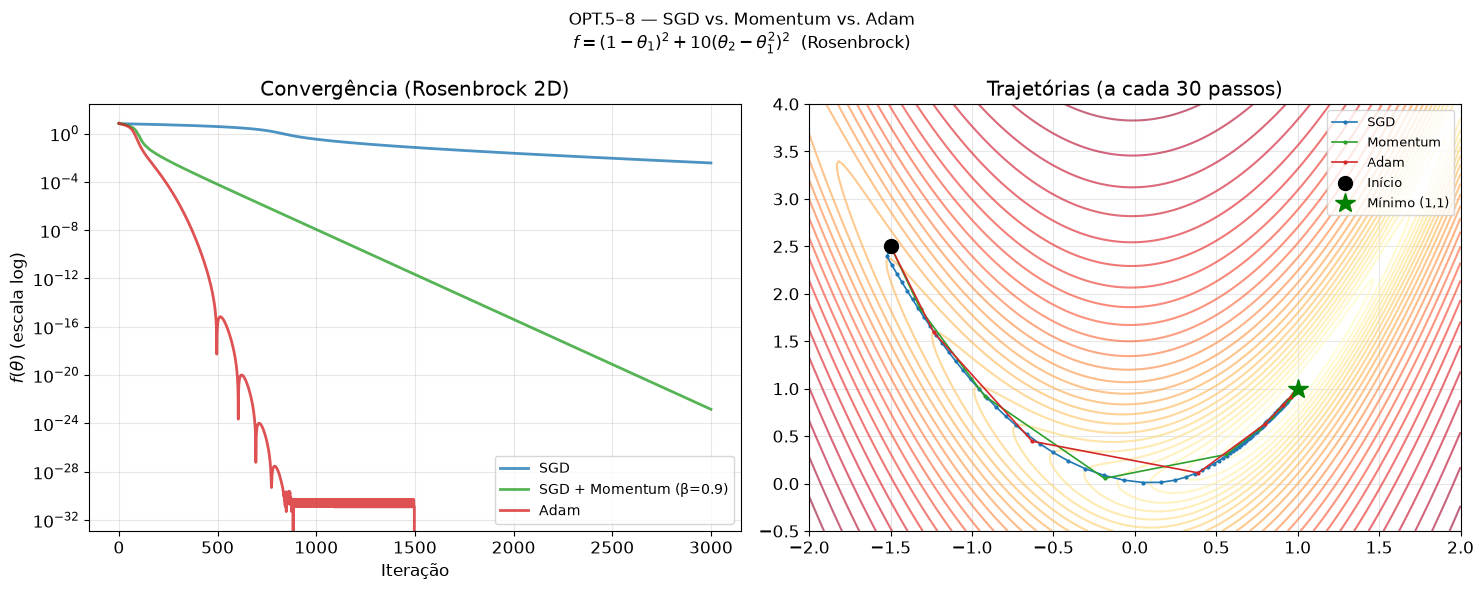

SGD final:      f = 0.003658
Momentum final: f = 0.000000
Adam final:     f = 0.00000000


In [14]:
# Comparação visual: SGD vs. Momentum vs. Adam (Função de Rosenbrock 2D)
import numpy as np
import matplotlib.pyplot as plt

def f_ros(theta):
    x, y = theta
    return (1 - x)**2 + 10*(y - x**2)**2

def grad_ros(theta):
    x, y = theta
    gx = -2*(1 - x) + 10*2*(y - x**2)*(-2*x)
    gy = 10*2*(y - x**2)
    return np.array([gx, gy])

def run_sgd(theta0, eta, n):
    path = [theta0.copy()]; theta = theta0.copy()
    for _ in range(n):
        theta = theta - eta * grad_ros(theta)
        path.append(theta.copy())
    return np.array(path)

def run_momentum(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_ros(theta)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

def run_adam(theta0, alpha, b1, b2, eps, n):
    path = [theta0.copy()]; theta = theta0.copy(); m = np.zeros(2); v = np.zeros(2)
    for t in range(1, n + 1):
        g = grad_ros(theta)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())
    return np.array(path)

theta0 = np.array([-1.5, 2.5])
n_steps = 3000

path_sgd  = run_sgd(theta0, eta=0.002, n=n_steps)
path_mom  = run_momentum(theta0, eta=0.002, beta=0.9, n=n_steps)
path_adam = run_adam(theta0, alpha=0.05, b1=0.9, b2=0.999, eps=1e-8, n=n_steps)

f_sgd  = [f_ros(p) for p in path_sgd]
f_mom  = [f_ros(p) for p in path_mom]
f_adam = [f_ros(p) for p in path_adam]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.semilogy(f_sgd,  'tab:blue',  lw=2, alpha=0.8, label='SGD')
ax.semilogy(f_mom,  'tab:green', lw=2, alpha=0.8, label='SGD + Momentum (β=0.9)')
ax.semilogy(f_adam, 'tab:red',   lw=2, alpha=0.8, label='Adam')
ax.set_xlabel('Iteração'); ax.set_ylabel('$f(\\theta)$ (escala log)')
ax.set_title('Convergência (Rosenbrock 2D)'); ax.legend(fontsize=10)

ax = axes[1]
x_g = np.linspace(-2, 2, 200); y_g = np.linspace(-0.5, 4, 200)
X, Y = np.meshgrid(x_g, y_g)
Z = (1 - X)**2 + 10*(Y - X**2)**2
ax.contour(X, Y, np.log(Z + 1), levels=30, cmap='YlOrRd', alpha=0.6)
step = 30
ax.plot(path_sgd[::step,0],  path_sgd[::step,1],  'tab:blue',  marker='.', ms=4, lw=1.2, label='SGD')
ax.plot(path_mom[::step,0],  path_mom[::step,1],  'tab:green', marker='.', ms=4, lw=1.2, label='Momentum')
ax.plot(path_adam[::step,0], path_adam[::step,1], 'tab:red',   marker='.', ms=4, lw=1.2, label='Adam')
ax.plot(*theta0, 'ko', ms=10, zorder=6, label='Início')
ax.plot(1, 1, 'g*', ms=15, zorder=6, label='Mínimo (1,1)')
ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 4)
ax.set_title('Trajetórias (a cada 30 passos)'); ax.legend(fontsize=9)

plt.suptitle('OPT.5–8 — SGD vs. Momentum vs. Adam\n$f = (1-\\theta_1)^2 + 10(\\theta_2-\\theta_1^2)^2$  (Rosenbrock)', fontsize=12)
plt.tight_layout(); plt.show()

print(f"SGD final:      f = {f_ros(path_sgd[-1]):.6f}")
print(f"Momentum final: f = {f_ros(path_mom[-1]):.6f}")
print(f"Adam final:     f = {f_ros(path_adam[-1]):.8f}")

## Fórmula OPT.9 — Métodos de Segunda Ordem: Newton e Quasi-Newton

### Newton Method

Usa uma **aproximação quadrática** ao redor do ponto atual (expansão de Taylor de 2ª ordem):

$$\boxed{\theta_{t+1} = \theta_t - H(\theta_t)^{-1} \nabla f(\theta_t)}$$

| Símbolo | Significado |
|---------|-------------|
| $H(\theta_t) = \nabla^2 f(\theta_t)$ | **Hessiana** — matriz de segundas derivadas (curvatura) |
| $H^{-1} \nabla f$ | **Direção de Newton** — gradiente pré-condicionado pela curvatura |

### Por que é mais eficiente (em iterações)?

O gradiente puro só sabe "para onde ir". A Hessiana informa **quão íngremes são as curvaturas** — o Newton ajusta o passo para ser maior em direções com pouca curvatura e menor onde a curvatura é alta.

Resultado: **convergência quadrática** perto do ótimo (vs. convergência linear do GD).

### Custo computacional

| Aspecto | Custo |
|---------|-------|
| Computar $H$ | $O(d^2)$ entradas por iteração |
| Inverter $H$ | $O(d^3)$ — proibitivo para $d > 10^4$ |

### Quasi-Newton: BFGS e L-BFGS

Evita computar a Hessiana exata: **aproxima $H^{-1}$ iterativamente** a partir de diferenças de gradiente.

$$s_t = \theta_{t+1} - \theta_t, \qquad y_t = \nabla f(\theta_{t+1}) - \nabla f(\theta_t)$$

| Método | Memória | Quando usar |
|--------|---------|-------------|
| **BFGS** | $O(d^2)$ — armazena matriz completa | Problemas de porte médio |
| **L-BFGS** | $O(m \cdot d)$ — armazena apenas $m$ pares $(s_t, y_t)$ | Modelos grandes |

> L-BFGS é popular para objetivos suaves e determinísticos com muitas variáveis. É o otimizador padrão de `scipy.optimize.minimize` e usado em regressão logística do sklearn.

---

# RESUMO GERAL — Todas as Fórmulas

---

## Tabela Mestre de Fórmulas

| # | Fórmula | Expressão | Objetivo |
|---|---------|-----------|----------|
| **1.1** | Problema Estatístico | $Y = f(\mathbf{x}) + \epsilon$ | Formalizar estrutura + ruído |
| **1.2** | Forma Matricial | $\mathbf{y} = X\mathbf{a} + \boldsymbol{\epsilon}$ | Representar todos os dados de uma vez |
| **1.3** | Normal Equations | $\hat{\mathbf{a}} = (X^TX)^{-1}X^T\mathbf{y}$ | Solução analítica exata do MSE |
| **1.4** | Basis Functions | $\hat{\mathbf{a}} = (B^TB)^{-1}B^T\mathbf{y}$ | Não-linearidade preservando álgebra linear |
| **1.5** | Polynomial Basis | $B_m(x) = x^m$ | Capturar curvaturas simples |
| **1.6** | Gaussian RBF | $B_m(x) = \exp(-(x-c_m)^2/2\sigma^2)$ | Suporte local, localidade |
| **1.7** | Fourier Basis | $\sin(2\pi kx/T), \cos(2\pi kx/T)$ | Dados periódicos |
| **1.8** | B-Splines (Cox-de Boor) | $B_{m,p}(x) = \frac{x-t_m}{t_{m+p}-t_m}B_{m,p-1} + \ldots$ | Localidade + suavidade + estabilidade |
| **2.1** | Decomposição MSE | $\text{Bias}^2 + \text{Variance} + \sigma^2$ | Diagnosticar e separar fontes de erro |
| **2.2** | Bias² | $(f(x) - \mathbb{E}[\hat{f}(x)])^2$ | Erro sistemático do modelo |
| **2.3** | Variance | $\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]$ | Sensibilidade ao dataset |
| **2.4** | K-Fold CV | $\text{CV}_K = \frac{1}{K}\sum_{k=1}^K \text{MSE}_k$ | Estimar erro de generalização |
| **3.1** | Soft Regularização | $\mathcal{L}(\theta) + \lambda\mathcal{R}(\theta)$ | Controlar complexidade |
| **3.2** | Ridge (L2) | $\hat{\theta} = (X^TX+\lambda I)^{-1}X^T\mathbf{y}$ | Encolhimento; invertibilidade |
| **3.3** | Lasso (L1) | $\min \text{MSE} + \lambda\|\theta\|_1$ | Esparsidade; feature selection |
| **3.4** | Elastic Net | $\lambda_1\|\theta\|_1 + \lambda_2\|\theta\|^2$ | Features correlacionadas |
| **3.5** | Early Stopping | $\hat{\theta}_{\text{ES}}(t) \approx \hat{\theta}_{\text{Ridge}}(1/\eta t)$ | Regularização implícita |
| **3.6** | Dropout | $\tilde{h}_j = m_j h_j$, $m_j \sim \text{Bernoulli}(1-p)$ | Ensemble implícito |
| **3.7** | Label Smoothing | $y_k^s = y_k(1-\epsilon) + \epsilon/K$ | Output regularization |
| **4.1** | Likelihood | $-\log p(\mathcal{D}\mid\theta) = \text{MSE}$ | Interpretação probabilística do MSE |
| **4.2** | Bayes | $p(\theta\mid\mathcal{D}) \propto p(\mathcal{D}\mid\theta)\cdot p(\theta)$ | Fundir prior com dados |
| **4.3** | Gaussian Prior → L2 | $\lambda = \sigma^2/\tau^2$ | Ridge como MAP com prior Gaussiano |
| **4.4** | Laplace Prior → L1 | $\lambda = \sigma^2/b$ | Lasso como MAP com prior de Laplace |
| **4.5** | Bootstrap IC | $[q_{2.5\%}(\{s^b\}), q_{97.5\%}(\{s^b\})]$ | Incerteza sem fórmulas analíticas |
| **OPT.1** | Convexidade | $f(\lambda\alpha+(1-\lambda)\beta) \leq \lambda f(\alpha)+(1-\lambda)f(\beta)$ | Garantia de mínimo global |
| **OPT.2** | Gradient Descent | $\theta_{t+1} = \theta_t - \eta_t \nabla f(\theta_t)$ | Descida iterativa pela inclinação |
| **OPT.3** | Momentum | $v_{t+1} = \beta v_t + \nabla f(\theta_t)$, $\theta_{t+1} = \theta_t - \eta_t v_{t+1}$ | EMA dos gradientes; acelerar |
| **OPT.4** | Nesterov | $v_{t+1} = \beta v_t + \nabla f(\theta_t - \eta\beta v_t)$ | Look-ahead gradient |
| **OPT.5** | SGD Minibatch | $\theta_{t+1} = \theta_t - \eta_t \nabla \ell_B(\theta_t)$ | Escalar para datasets grandes |
| **OPT.6** | AdaGrad | $G_t = G_{t-1}+g_t^2$, $\theta_t = \theta_{t-1} - \eta g_t/\sqrt{G_t+\varepsilon}$ | LR adaptativo por coordenada |
| **OPT.7** | AdaDelta | $\Delta\theta_t = -\text{RMS}[\Delta\theta]_{t-1}/\text{RMS}[g]_t \cdot g_t$ | EMA janelada; evita LR→0 |
| **OPT.8** | Adam | $\theta_t = \theta_{t-1} - \alpha\hat{m}_t/(\sqrt{\hat{v}_t}+\varepsilon)$ | Momentum + escala adaptativa |
| **OPT.9** | Newton / L-BFGS | $\theta_{t+1} = \theta_t - H^{-1}\nabla f(\theta_t)$ | Convergência quadrática com curvatura |

---

## Mapa Mental das Conexões

```
Y = f(x) + ε  (Fórmula 1.1)
│
├── Estimação de f
│   ├── Regressão Linear: â = (XᵀX)⁻¹Xᵀy  (F1.3)
│   └── Basis Functions: â = (BᵀB)⁻¹Bᵀy  (F1.4)
│       ├── Polynomial: Bm(x) = xᵐ  (F1.5)
│       ├── RBF: exp(-(x-cm)²/2σ²)  (F1.6)
│       ├── Fourier: sin/cos(2πkx/T)  (F1.7)
│       └── B-Splines: Cox-de Boor  (F1.8)
│
├── Diagnóstico do Modelo
│   └── MSE = Bias² + Variance + σ²  (F2.1, F2.2, F2.3)
│       └── Estimado via K-Fold CV = (1/K)Σ MSEk  (F2.4)
│
├── Controle da Complexidade (Regularização)
│   ├── Soft: L(θ) + λR(θ)  (F3.1)
│   │   ├── Ridge (L2): (XᵀX+λI)⁻¹Xᵀy  (F3.2)
│   │   ├── Lasso (L1): min MSE + λ||θ||₁  (F3.3)
│   │   └── Elastic Net: λ₁||θ||₁ + λ₂||θ||²  (F3.4)
│   ├── Early Stopping ≈ Ridge  (F3.5)
│   ├── Dropout: h̃j = mj·hj  (F3.6)
│   └── Label Smoothing: yk(1-ε)+ε/K  (F3.7)
│
├── Visão Probabilística
│   ├── -log Likelihood = MSE  (F4.1)
│   ├── Bayes: p(θ|D) ∝ p(D|θ)·p(θ)  (F4.2)
│   ├── Gaussian Prior → Ridge λ=σ²/τ²  (F4.3)
│   ├── Laplace Prior → Lasso λ=σ²/b  (F4.4)
│   └── Bootstrap IC = [q₂.₅%, q₉₇.₅%]  (F4.5)
│
└── Otimização (como minimizar f(θ))
    ├── Convexidade: f(λα+(1-λ)β) ≤ λf(α)+(1-λ)f(β)  (OPT.1)
    │   └── Garante que mínimo local = mínimo global
    │
    ├── Métodos de 1ª Ordem (só gradiente)
    │   ├── GD Batch: θₜ₊₁ = θₜ - ηₜ∇f(θₜ)  (OPT.2)
    │   ├── Momentum: vₜ₊₁ = βvₜ + ∇f(θₜ)  (OPT.3)  ← EMA dos gradientes
    │   ├── Nesterov: vₜ₊₁ = βvₜ + ∇f(θₜ - ηβvₜ)  (OPT.4)  ← look-ahead
    │   └── SGD Minibatch: θₜ₊₁ = θₜ - ηₜ∇ℓ_B(θₜ)  (OPT.5)  ← escala
    │
    ├── Métodos Adaptativos (LR por coordenada)
    │   ├── AdaGrad: θₜ -= η·gₜ/√(Gₜ+ε)  (OPT.6)  ← soma histórica
    │   ├── AdaDelta: θₜ += -RMS[Δθ]/RMS[g]·gₜ  (OPT.7)  ← EMA janelada
    │   └── Adam: θₜ -= α·m̂ₜ/(√v̂ₜ+ε)  (OPT.8)  ← momentum + AdaGrad com EMA
    │
    └── Métodos de 2ª Ordem (gradiente + curvatura)
        ├── Newton: θₜ₊₁ = θₜ - H(θₜ)⁻¹∇f(θₜ)  (OPT.9)
        └── L-BFGS: aproximação iterativa de H⁻¹  (OPT.9)
```

---

## Quick Reference — Fórmulas de Bolso

| Situação | Fórmula |
|----------|---------|
| Ajustar modelo linear | $\hat{\mathbf{a}} = (X^TX)^{-1}X^T\mathbf{y}$ |
| Problema mal-condicionado ($p > K$) | $\hat{\theta} = (X^TX + \lambda I)^{-1}X^T\mathbf{y}$ |
| Diagnóstico de overfitting | Gap grande treino/val → Variance alta |
| Diagnóstico de underfitting | Ambos altos → Bias² alto |
| Escolher $\lambda$ | Log-grid: `np.logspace(-5, 5, 20)` → K-Fold CV |
| Quero sparsidade | Lasso ($\lambda\|\theta\|_1$) |
| Quero encolhimento suave | Ridge ($\lambda\|\theta\|^2$) |
| Features correlacionadas | Elastic Net |
| Estimar incerteza | Bootstrap: reamostrar com reposição $B$ vezes |
| Reduzir Variance sem mais dados | Bagging / Dropout / Ridge |
| **Otimizar com muitos dados** | **SGD Minibatch:** $\theta \leftarrow \theta - \eta \nabla\ell_B(\theta)$ |
| **Acelerar SGD em vales estreitos** | **Momentum** ($\beta=0.9$): acumula velocidade |
| **Default para redes neurais** | **Adam** ($\alpha=0.001$, $\beta_1=0.9$, $\beta_2=0.999$) |
| **Deep learning com regularização** | **AdamW** (weight decay separado da adaptação) |
| **Modelos clássicos (sklearn)** | **L-BFGS** via `scipy.optimize.minimize` |
| **Verificar se o problema é convexo** | Toda soma ponderada entre pontos fica acima da curva? |

---

> **Referências:**
> - `lectures understanding/L1_General_Linear_Models_Basis_Functions.ipynb`
> - `lectures understanding/L2_Bias_Variance_Model_Selection.ipynb`
> - `lectures understanding/L3_Regularization_CrossValidation.ipynb`
> - `lectures understanding/L4_Probabilistic_View_Bayesian_Regularization.ipynb`
> - `lectures/Statistisches_Lernen_2_v4.pdf` — Capítulo de Otimização